# Анализ и выделение признаков - лабораторная работа

## ИУ5 ОАД

### Цель:
Научиться анализировать данные и выделять из них полезные признаки, научиться пользоваться `seaborn` и `sklearn`, познакомиться с основными понятиями Data Science.

**Обратите внимание**, что в каждом разделе лабораторной работы есть оцениваниемые задачи и есть вопросы. Вопросы дополняют задачи и направлены на то, чтобы проинтерпретировать или обосновать происходящее. Код без интерпретации не имеет смысла, поэтому отвечать на вопросы обязательно — отсутствие ответов приравнивается к невыполненной лабораторной работе. Ответы без кода – аналогично.

In [ ]:
#!pip install pandas matplotlib seaborn

В этом ноутбуке используется библиотека `folium` для визуализации карт. Она работает в google colab!

In [1]:
!pip install folium


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
import folium

m = folium.Map(location=(55.7522200, 37.6155600), zoom_start=10)

m

Если вы всё сделали правильно, то выше должна открыться карта Москвы.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set(style="darkgrid")

np.random.seed(0)

## Часть 0. Подготовка (1 балл)

**Задание 1**. Мы будем работать с данными из соревнования [New York City Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration/overview), в котором нужно было предсказать длительность поездки на такси. Скачайте обучающую выборку из этого соревнования и загрузите ее:

In [21]:
# ВАШ КОД ТУТ
df = pd.read_csv('nyc-taxi-trip-duration/train.csv')
print(df.head())

          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -73.999481   
2                1        -73.979027        40.763939         -74.005333   
3                1        -74.010040        40.719971         -74.012268   
4                1        -73.973053        40.793209         -73.972923   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.765602                  N            455  
1         40.731

Обратите внимание на колонки `pickup_datetime` и `dropoff_datetime`. `dropoff_datetime` был добавлена организаторами только в обучающую выборку, то есть использовать эту колонку для обучения модели машинного обучения нельзя, давайте удалим ее. В `pickup_datetime` записаны дата и время начала поездки. Чтобы с ней было удобно работать, давайте преобразуем даты в `datetime`-объекты

In [23]:
# ВАШ КОД ТУТ
df.drop(columns=['dropoff_datetime'], inplace=True)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
print(df.head())

          id  vendor_id     pickup_datetime  passenger_count  \
0  id2875421          2 2016-03-14 17:24:55                1   
1  id2377394          1 2016-06-12 00:43:35                1   
2  id3858529          2 2016-01-19 11:35:24                1   
3  id3504673          2 2016-04-06 19:32:31                1   
4  id2181028          2 2016-03-26 13:30:55                1   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.982155        40.767937         -73.964630         40.765602   
1        -73.980415        40.738564         -73.999481         40.731152   
2        -73.979027        40.763939         -74.005333         40.710087   
3        -74.010040        40.719971         -74.012268         40.706718   
4        -73.973053        40.793209         -73.972923         40.782520   

  store_and_fwd_flag  trip_duration  
0                  N            455  
1                  N            663  
2                  N           2124  


**Вопрос**: Почему нельзя использовать `dropoff_datetime` для обучения модели машинного обучения? Какие есть противоречия?

Если у нас есть dropoff_datetime, мы можем точно вычислить целевую переменную, что делает модель бессмысленной

В колонке `trip_duration` записано целевое значение, которое мы хотим предсказывать. Давайте посмотрим на распределение таргета в обучающей выборке. Для этого нарисуйте его гистограмму:

<Figure size 1200x600 with 0 Axes>

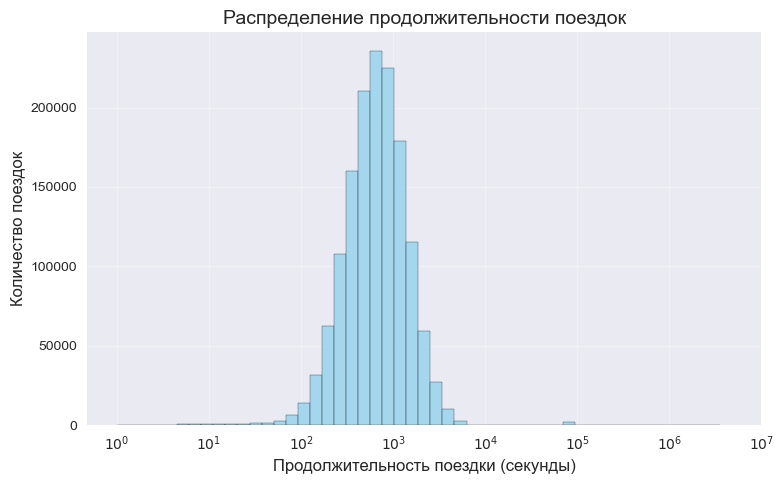

In [70]:
# ВАШ КОД ТУТ
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)

# Построение гистограммы распределения trip_duration
plt.figure(figsize=(12, 6))

# Гистограмма с подгонкой KDE
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))

ax1.hist(np.log10(df['trip_duration']), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_title('Распределение продолжительности поездок', fontsize=14)
ax1.set_xlabel('Продолжительность поездки (секунды)', fontsize=12)
ax1.set_ylabel('Количество поездок', fontsize=12)
ax1.grid(True, alpha=0.3)

min_log = np.log10(df['trip_duration']).min()
max_log = np.log10(df['trip_duration']).max()

ticks_positions = np.arange(np.floor(min_log), np.ceil(max_log) + 1)
ticks_labels = [f'$10^{{{int(pos)}}}$' for pos in ticks_positions]

ax1.set_xticks(ticks_positions)
ax1.set_xticklabels(ticks_labels)

plt.tight_layout()
plt.show()


**Вопрос**: Что можно сказать о целевой переменной по гистограмме её значений?

Максимальная частота в самом начале (близко к 0 секунд)


## Часть 1. Изучаем `pickup_datetime`

**Задание 2**. Для начала давайте посмотрим, сколько всего было поездок в каждый из дней. Постройте график зависимости количества поездок от дня в году (например, можно воспользоваться `sns.countplot`):

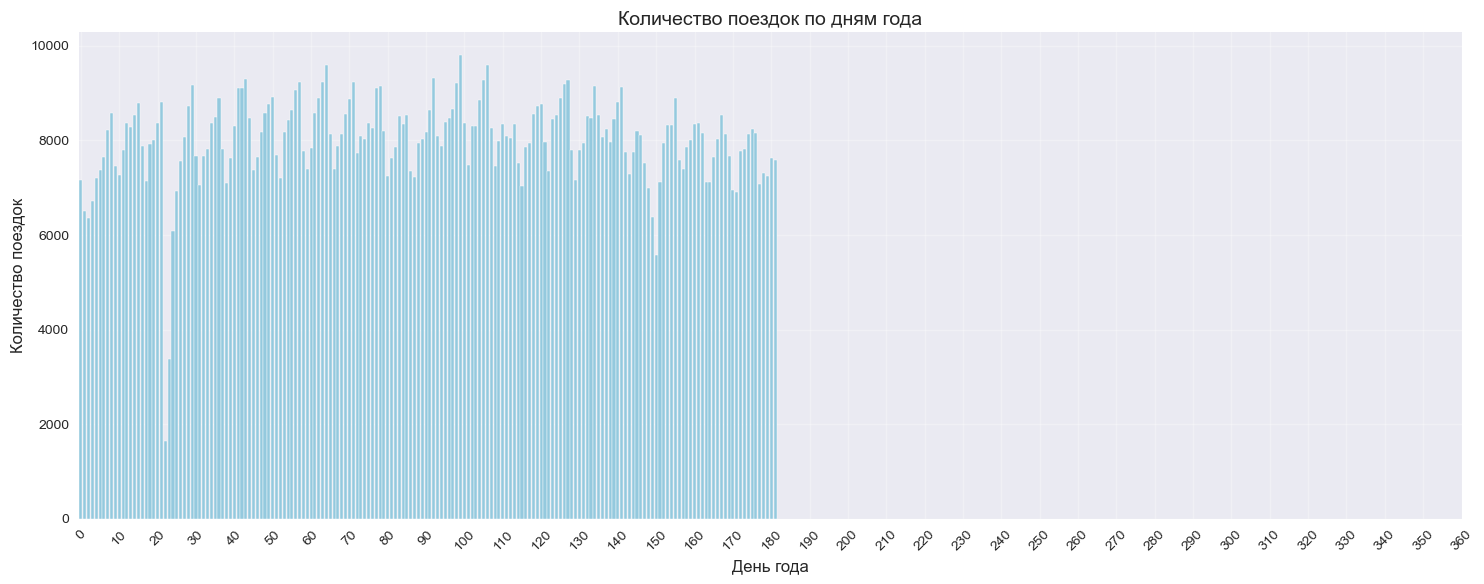

In [94]:
# ВАШ КОД ТУТ
df['pickup_day_of_year'] = df['pickup_datetime'].dt.dayofyear
# Построим countplot
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='pickup_day_of_year', color='skyblue')
plt.title('Количество поездок по дням года', fontsize=14)
plt.xlabel('День года', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.xticks(rotation=45)

# Чтобы не загромождать график, покажем каждую 10-ю метку
day_ticks = range(0, 366, 10)
plt.xticks(day_ticks, day_ticks)
df.drop(columns=['pickup_day_of_year'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Вопрос**: Вы, вероятно, заметили, что на графике есть 2 периода с аномально маленькими количествами поездок. Вычислите, в какие даты происходили эти скачки вниз и найдите информацию о том, что происходило в эти дни в Нью-Йорке.

Нарисуйте графики зависимости количества поездок от дня недели и от часов в сутках (воспользуйтесь `sns.relplot`):

Дни с аномально низким количеством поездок:
День года 23: 1648 поездок, дата: 2016-01-23
День года 24: 3383 поездок, дата: 2016-01-24


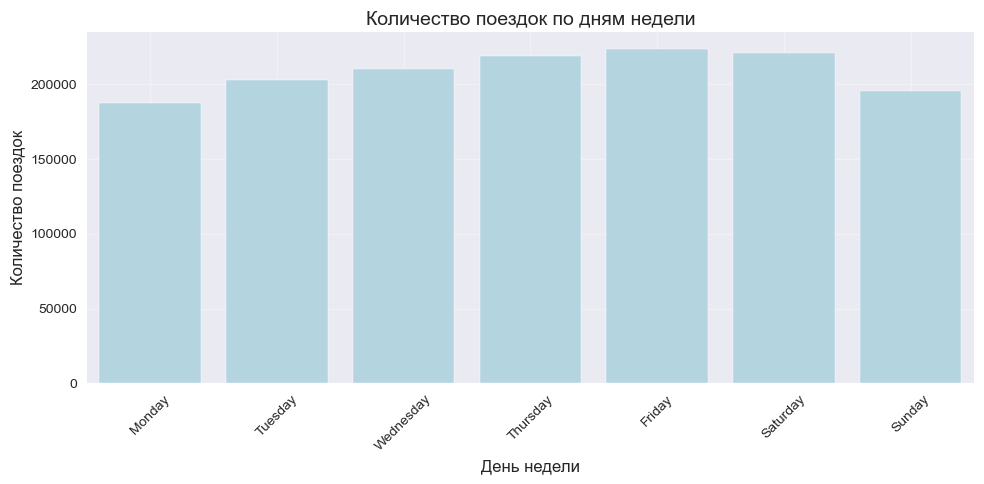

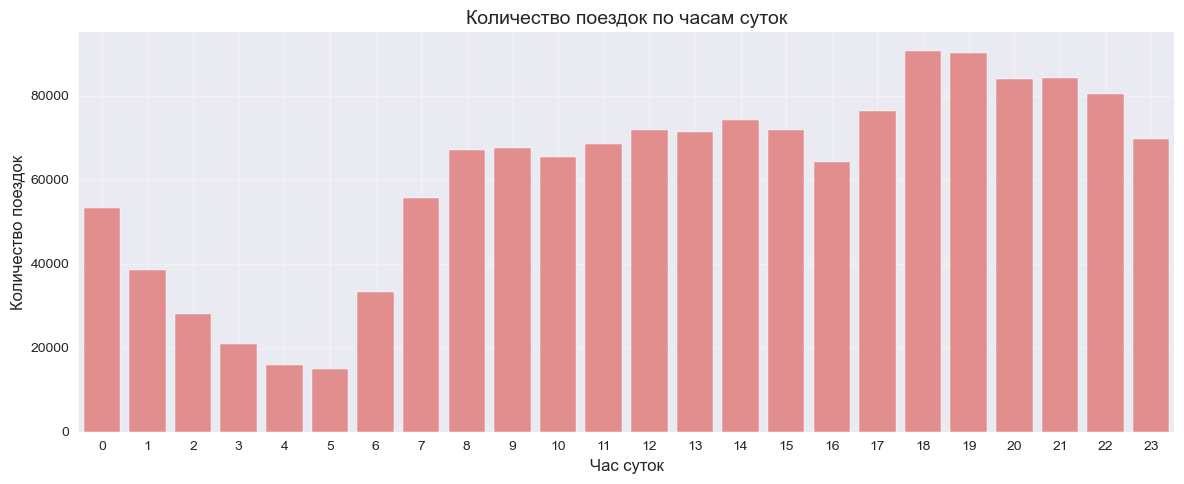

In [97]:
# ВАШ КОД ТУТ
# Найдем дни с аномально низким количеством поездок
daily_counts = df['pickup_day_of_year'].value_counts().sort_index()
anomalous_days = daily_counts.nsmallest(2)

print("Дни с аномально низким количеством поездок:")
for day, count in anomalous_days.items():
    date = df[df['pickup_day_of_year'] == day]['pickup_datetime'].iloc[0]
    print(f"День года {day}: {count} поездок, дата: {date.strftime('%Y-%m-%d')}")

# График зависимости количества поездок от дня недели
df['pickup_weekday'] = df['pickup_datetime'].dt.day_name()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='pickup_weekday', 
              order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
              color='lightblue')
plt.title('Количество поездок по дням недели', fontsize=14)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# График зависимости количества поездок от часа суток
df['pickup_hour'] = df['pickup_datetime'].dt.hour

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='pickup_hour', color='lightcoral')
plt.title('Количество поездок по часам суток', fontsize=14)
plt.xlabel('Час суток', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Задание 3**. Нарисуйте на одном графике зависимости количества поездок от часа в сутках для разных месяцев (разные кривые, соответствующие разным месяцам, окрашивайте в разные цвета, воспользуйтесь `hue` в `sns.relplot`). Аналогично нарисуйте зависимости количества поездок от часа в сутках для разных дней недели.

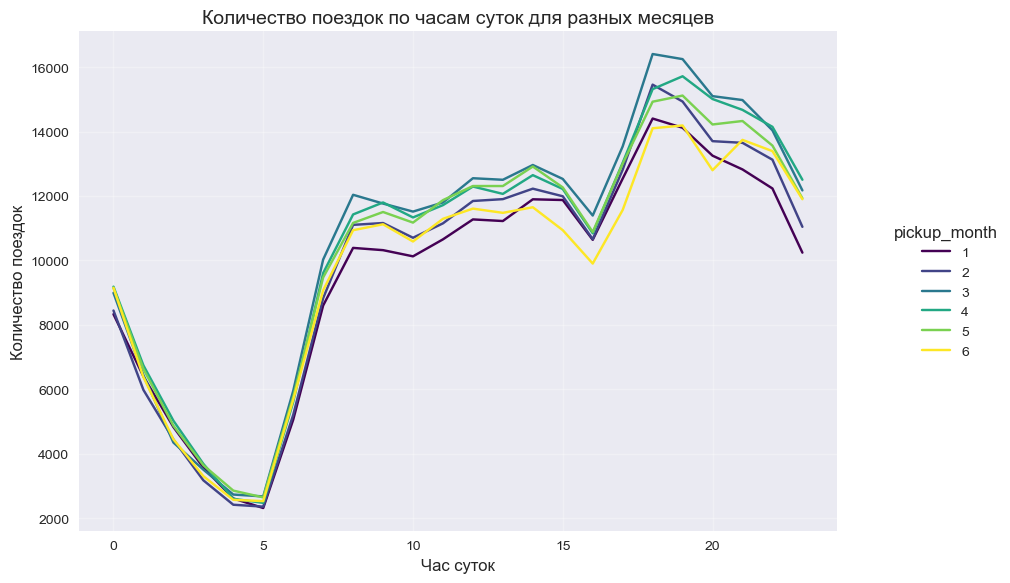

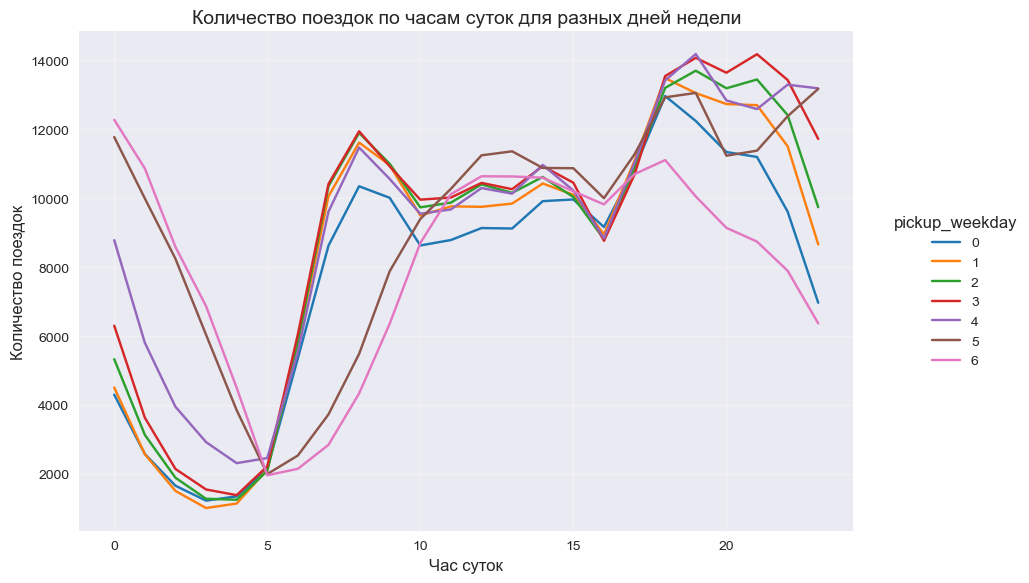

In [138]:
# ВАШ КОД ТУТ
# Создаем колонки для месяца и дня недели
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_weekday'] = df['pickup_datetime'].dt.dayofweek  # 0=понедельник, 6=воскресенье
df['pickup_hour'] = df['pickup_datetime'].dt.hour

# Группируем данные для построения графиков
monthly_hourly = df.groupby(['pickup_month', 'pickup_hour']).size().reset_index(name='count')
weekday_hourly = df.groupby(['pickup_weekday', 'pickup_hour']).size().reset_index(name='count')

# График по месяцам
g1 = sns.relplot(data=monthly_hourly, x='pickup_hour', y='count', 
                 hue='pickup_month', kind='line', palette='viridis', 
                 height=6, aspect=1.5)
plt.title('Количество поездок по часам суток для разных месяцев', fontsize=14)
plt.xlabel('Час суток', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# График по дням недели
g2 = sns.relplot(data=weekday_hourly, x='pickup_hour', y='count', 
                 hue='pickup_weekday', kind='line', palette='tab10',
                 height=6, aspect=1.5)
plt.title('Количество поездок по часам суток для разных дней недели', fontsize=14)
plt.xlabel('Час суток', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

**Вопрос**: Какие выводы можно сделать, основываясь на графиках выше? Выделяются ли какие-нибудь дни недели? Месяца? Время суток? С чем это связано?

**Задание 4**. Разбейте выборку на обучающую и тестовую в отношении 7:3, представьте, что вы готовите данные для обучения модели машинного обучения (используйте `train_test_split` из `sklearn`). По обучающей выборке нарисуйте график зависимости среднего логарифма времени поездки от дня недели. Затем сделайте то же самое, но для часа в сутках и дня в году.

Размер обучающей выборки: 1021050
Размер тестовой выборки: 437594


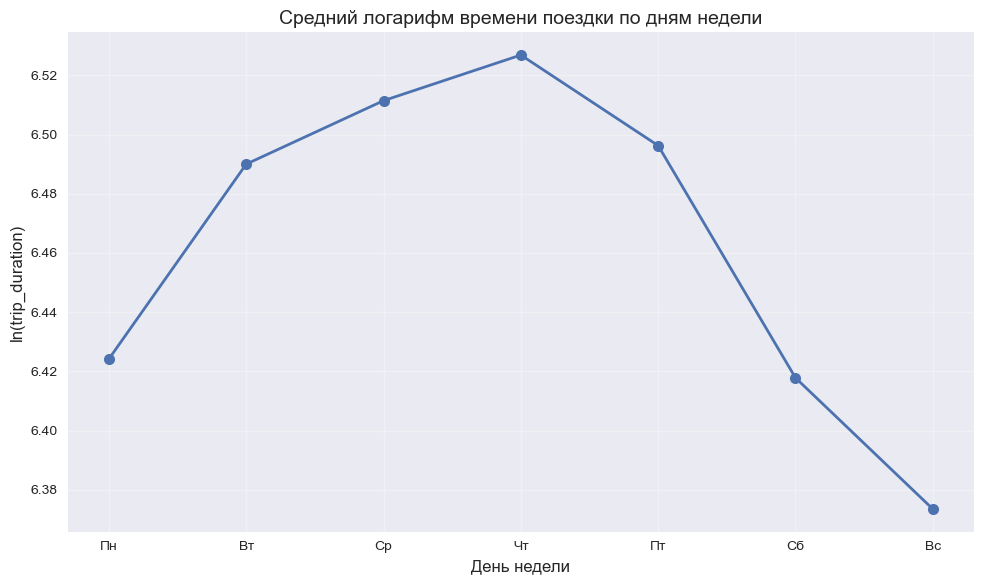

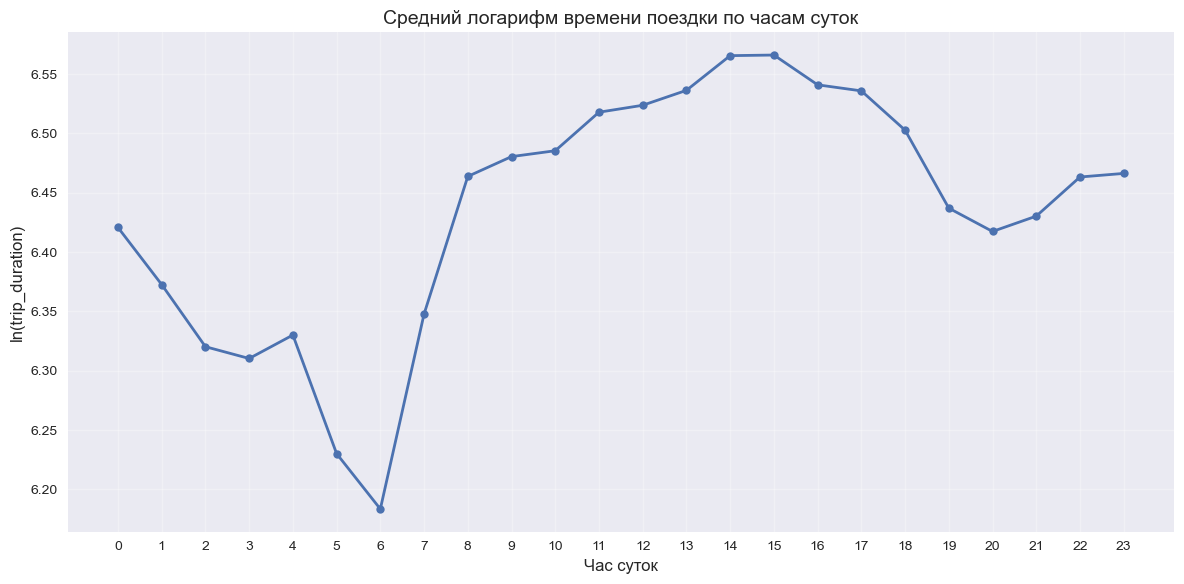

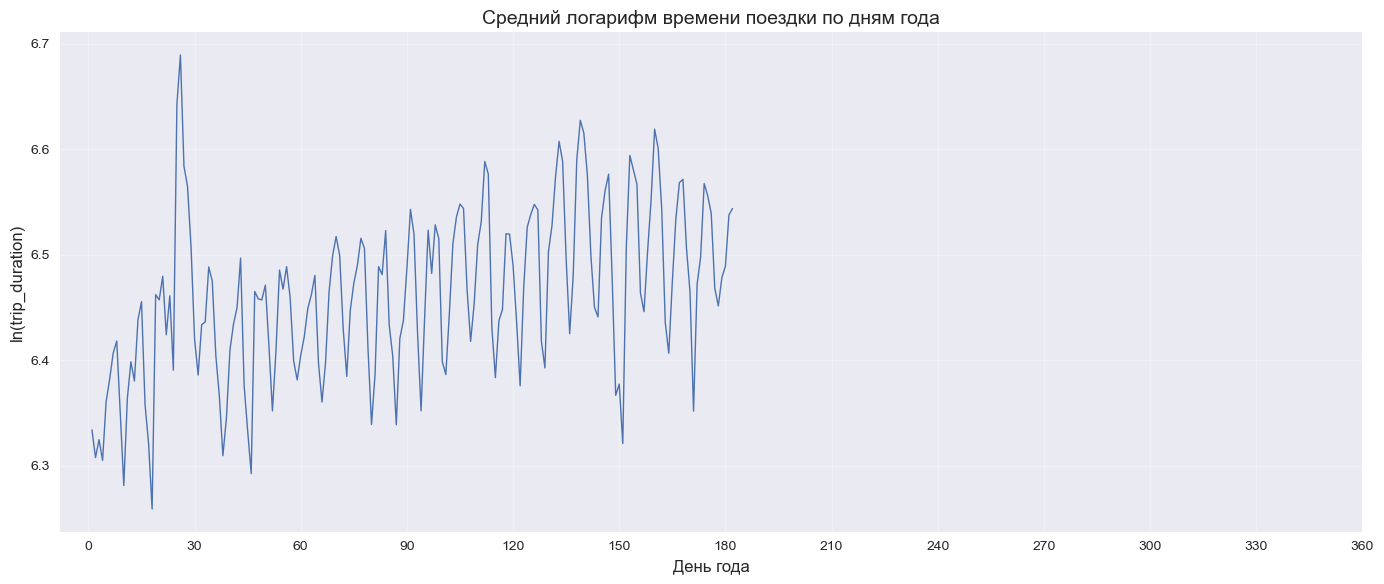

In [143]:
# ВАШ КОД ТУТ
from sklearn.model_selection import train_test_split

# Разбиваем данные на обучающую и тестовую выборки
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")

# Создаем логарифмированную целевую переменную
train_df['log_trip_duration'] = np.log(train_df['trip_duration'])

# График 1: Зависимость среднего логарифма времени поездки от дня недели
plt.figure(figsize=(10, 6))
weekday_means = train_df.groupby('pickup_weekday')['log_trip_duration'].mean()
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

plt.plot(weekday_names, weekday_means, marker='o', linewidth=2, markersize=8)
plt.title('Средний логарифм времени поездки по дням недели', fontsize=14)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('ln(trip_duration)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# График 2: Зависимость среднего логарифма времени поездки от часа в сутках
plt.figure(figsize=(12, 6))
hourly_means = train_df.groupby('pickup_hour')['log_trip_duration'].mean()

plt.plot(hourly_means.index, hourly_means.values, marker='o', linewidth=2, markersize=6)
plt.title('Средний логарифм времени поездки по часам суток', fontsize=14)
plt.xlabel('Час суток', fontsize=12)
plt.ylabel('ln(trip_duration)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# График 3: Зависимость среднего логарифма времени поездки от дня в году
plt.figure(figsize=(14, 6))
daily_means = train_df.groupby('pickup_day_of_year')['log_trip_duration'].mean()

plt.plot(daily_means.index, daily_means.values, linewidth=1)
plt.title('Средний логарифм времени поездки по дням года', fontsize=14)
plt.xlabel('День года', fontsize=12)
plt.ylabel('ln(trip_duration)', fontsize=12)
plt.grid(True, alpha=0.3)

# Чтобы не загромождать график, покажем каждую 30-ю метку
day_ticks = range(0, 366, 30)
plt.xticks(day_ticks, day_ticks)

plt.tight_layout()
plt.show()

**Вопрос**: Похожи ли графики зависимости таргета от дня недели и от часа в сутках на аналогичные графики для количества поездок? Почему? Что происходит со средним таргетом в те два аномальных периода, что мы видели выше? Почему так происходит? Наблюдаете ли вы какой-нибудь тренд на графике зависимости `log_trip_duration` от номера дня в году?

Добавьте следующие признаки на основе `pickup_datetime`:
1. День недели
2. Месяц
3. Час
4. Является ли период аномальным (два бинарных признака, соответствующие двум аномальным периодам)
5. Номер дня в году

In [146]:
# ВАШ КОД ТУТ
# Создаем копию датафрейма для добавления новых признаков
df_with_features = df.copy()

# 1. День недели (уже есть)
df_with_features['weekday'] = df_with_features['pickup_datetime'].dt.dayofweek

# 2. Месяц (уже есть) 
df_with_features['month'] = df_with_features['pickup_datetime'].dt.month

# 3. Час (уже есть)
df_with_features['hour'] = df_with_features['pickup_datetime'].dt.hour

# 4. Номер дня в году (уже есть)
df_with_features['day_of_year'] = df_with_features['pickup_datetime'].dt.dayofyear

# 5. Определяем аномальные периоды (на основе предыдущего анализа)
# Найдем дни с аномально низким количеством поездок
daily_counts = df_with_features['day_of_year'].value_counts().sort_index()
anomalous_days = daily_counts.nsmallest(2).index.tolist()

print(f"Аномальные дни (номера в году): {anomalous_days}")

# Создаем бинарные признаки для аномальных периодов
df_with_features['is_anomalous_period_1'] = (df_with_features['day_of_year'] == anomalous_days[0]).astype(int)
df_with_features['is_anomalous_period_2'] = (df_with_features['day_of_year'] == anomalous_days[1]).astype(int)

# Также можно создать общий признак для любых аномальных дней
df_with_features['is_any_anomalous'] = (df_with_features['is_anomalous_period_1'] | 
                                       df_with_features['is_anomalous_period_2']).astype(int)

# Проверим созданные признаки
print("\nСозданные временные признаки:")
print(df_with_features[['pickup_datetime', 'weekday', 'month', 'hour', 
                       'day_of_year', 'is_anomalous_period_1', 
                       'is_anomalous_period_2', 'is_any_anomalous']].head(10))

print(f"\nСтатистика аномальных периодов:")
print(f"Аномальный период 1: {df_with_features['is_anomalous_period_1'].sum()} поездок")
print(f"Аномальный период 2: {df_with_features['is_anomalous_period_2'].sum()} поездок")
print(f"Всего аномальных поездок: {df_with_features['is_any_anomalous'].sum()}")

# Дополнительные полезные временные признаки
df_with_features['is_weekend'] = (df_with_features['weekday'] >= 5).astype(int)
df_with_features['is_rush_hour'] = ((df_with_features['hour'] >= 7) & (df_with_features['hour'] <= 9) | 
                                   (df_with_features['hour'] >= 16) & (df_with_features['hour'] <= 19)).astype(int)

print(f"\nДополнительные признаки:")
print(f"Выходные дни: {df_with_features['is_weekend'].sum()} поездок")
print(f"Часы пик: {df_with_features['is_rush_hour'].sum()} поездок")

Аномальные дни (номера в году): [23, 24]

Созданные временные признаки:
      pickup_datetime  weekday  month  hour  day_of_year  \
0 2016-03-14 17:24:55        0      3    17           74   
1 2016-06-12 00:43:35        6      6     0          164   
2 2016-01-19 11:35:24        1      1    11           19   
3 2016-04-06 19:32:31        2      4    19           97   
4 2016-03-26 13:30:55        5      3    13           86   
5 2016-01-30 22:01:40        5      1    22           30   
6 2016-06-17 22:34:59        4      6    22          169   
7 2016-05-21 07:54:58        5      5     7          142   
8 2016-05-27 23:12:23        4      5    23          148   
9 2016-03-10 21:45:01        3      3    21           70   

   is_anomalous_period_1  is_anomalous_period_2  is_any_anomalous  
0                      0                      0                 0  
1                      0                      0                 0  
2                      0                      0                

Итак, мы уже создали некоторое количество признаков.

**Вопрос**: Какие из признаков _стоит рассматривать в этой задаче_   как категориальные, а какие - как численные? Почему?

## Часть 2. Изучаем координаты
Мы уже очень хорошо изучили данные о времени начала поездки, давайте теперь посмотрим на информацию о координатах начала и конца поездки. Мы подготовили для вас функцию, которая на карте рисует точки начала или конца поездки. Примеры ее вызова вы найдете ниже. Обратите внимание, что в эту функцию мы передаем лишь небольшой кусочек данных, посколько иначе функция будет работать очень долго

In [149]:
def show_circles_on_map(data, latitude_column, longitude_column, color):
    """
    The function draws map with circles on it.
    The center of the map is the mean of coordinates passed in data.
    
    data: DataFrame that contains columns latitude_column and longitude_column
    latitude_column: string, the name of column for latitude coordinates
    longitude_column: string, the name of column for longitude coordinates
    color: string, the color of circles to be drawn
    """

    location = (data[latitude_column].mean(), data[longitude_column].mean())
    m = folium.Map(location=location)

    for _, row in data.iterrows():
        folium.Circle(
            radius=100,
            location=(row[latitude_column], row[longitude_column]),
            color=color,
            fill_color=color,
            fill=True
        ).add_to(m)

    return m

In [151]:
show_circles_on_map(df.sample(1000), "pickup_latitude", "pickup_longitude", "blue")

In [153]:
show_circles_on_map(df.sample(1000), "dropoff_latitude", "dropoff_longitude", "blue")

**Вопрос**: Какие пункты (или скопления точек, в количестве 2-3), по вашему мнению, выделяются на карте от основной массы и могут быть полезны для нашей задачи? Почему вы их выбрали? В чём особенность этих скоплений точек для нашей задачи?

аэропорт центр

**Задание 5**. Как мы все прекрасно помним, $t = s / v_{\text{ср}}$, поэтому очевидно, что самым сильным признаком будет расстояние, которое необходимо проехать. Мы не можем посчитать точное расстояние, которое необходимо преодолеть такси, но мы можем его оценить, посчитав кратчайшее расстояние между точками начала и конца поездки. Чтобы корректно посчитать расстояние между двумя точками на Земле, можно использовать функцию `haversine`. Посчитайте кратчайшее расстояние для объектов и запишите его в колонку `haversine`:

In [164]:
# ВАШ КОД ТУТ
# !pip install haversine
from haversine import haversine

def calculate_haversine(row):
    pickup = (row['pickup_latitude'], row['pickup_longitude'])
    dropoff = (row['dropoff_latitude'], row['dropoff_longitude'])
    return haversine(pickup, dropoff)

df_with_features['haversine'] = df_with_features.apply(calculate_haversine, axis=1)

Так как мы можем предсказывать логарифм времени поездки и хотим, чтобы наши признаки были линейно зависимы с этой целевой переменной, нам нужно логарифмировать расстояние: $\log t = \log s - \log{v_{\text{ср}}}$. Запишите логарифм `haversine` в отдельную колонку `log_haversine`:

Статистика логарифмированных расстояний:
Минимальное log_haversine: 0.0000
Максимальное log_haversine: 7.1244
Среднее log_haversine: 1.2546
Медианное log_haversine: 1.1294


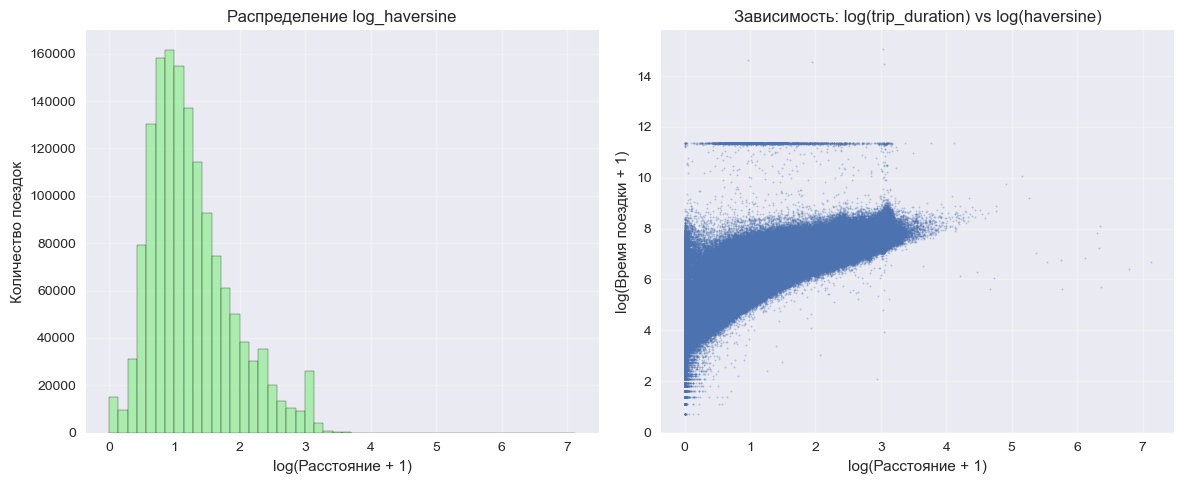


Корреляция между log_haversine и log(trip_duration): 0.7499

Первые 5 записей с расстояниями:
   haversine  log_haversine  trip_duration
0   1.498523       0.915700            455
1   1.805510       1.031585            663
2   6.385107       1.999465           2124
3   1.485500       0.910474            429
4   1.188590       0.783258            435


In [175]:
# ВАШ КОД ТУТ
# Логарифмируем расстояние haversine
df_with_features['log_haversine'] = np.log1p(df_with_features['haversine'])

# Посмотрим на результаты
print("Статистика логарифмированных расстояний:")
print(f"Минимальное log_haversine: {df_with_features['log_haversine'].min():.4f}")
print(f"Максимальное log_haversine: {df_with_features['log_haversine'].max():.4f}")
print(f"Среднее log_haversine: {df_with_features['log_haversine'].mean():.4f}")
print(f"Медианное log_haversine: {df_with_features['log_haversine'].median():.4f}")

# Визуализируем распределение
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_with_features['log_haversine'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Распределение log_haversine')
plt.xlabel('log(Расстояние + 1)')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Проверим линейную зависимость с логарифмом времени поездки
plt.scatter(df_with_features['log_haversine'], np.log1p(df_with_features['trip_duration']), 
            alpha=0.3, s=1)
plt.title('Зависимость: log(trip_duration) vs log(haversine)')
plt.xlabel('log(Расстояние + 1)')
plt.ylabel('log(Время поездки + 1)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Проверим корреляцию
correlation = np.corrcoef(df_with_features['log_haversine'], np.log1p(df_with_features['trip_duration']))[0, 1]
print(f"\nКорреляция между log_haversine и log(trip_duration): {correlation:.4f}")

# Посмотрим на первые несколько значений
print("\nПервые 5 записей с расстояниями:")
print(df_with_features[['haversine', 'log_haversine', 'trip_duration']].head())

Убедимся, что логарифм расстояния лучше коррелирует с нашим таргетом, чем просто расстояние:

In [179]:
df_with_features['log_trip_duration'] = np.log(df_with_features['trip_duration'])

your_df = df_with_features.copy()
assert your_df['log_haversine'].corr(your_df['log_trip_duration']) > your_df['haversine'].corr(your_df['log_trip_duration'])

**Задание 6**. Давайте изучим среднюю скорость движения такси. Посчитайте среднюю скорость для каждого объекта обучающей выборки, разделив `haversine` на `trip_duration`, и нарисуйте гистограмму ее распределения

/var/folders/wq/tf0mhtq56yn2f2vpbxk2jfpr0000gn/T/ipykernel_6400/2547161305.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['avg_speed'] = (train_df['haversine'] / (train_df['trip_duration'] / 3600))  # переводим секунды в часы


Статистика средней скорости (км/ч):
Минимальная скорость: 0.00 км/ч
Максимальная скорость: 9274.85 км/ч
Средняя скорость: 14.43 км/ч
Медианная скорость: 12.80 км/ч


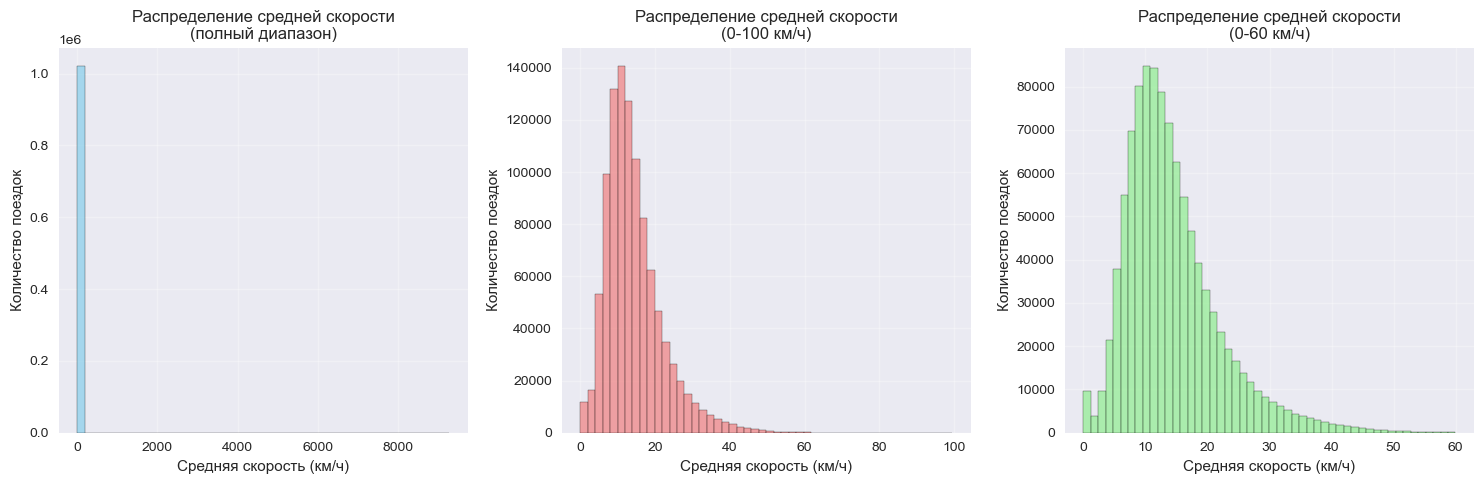


Анализ аномальных скоростей:
Количество поездок со скоростью > 100 км/ч: 125
Количество поездок со скоростью > 150 км/ч: 67
Количество поездок с нулевой скоростью: 4110

Процентили скорости (км/ч):
1%: 1.42 км/ч
5%: 5.05 км/ч
25%: 9.13 км/ч
50%: 12.80 км/ч
75%: 17.85 км/ч
95%: 29.46 км/ч
99%: 40.75 км/ч


In [183]:
# ВАШ КОД ТУТ
# Создаем копию обучающей выборки (из предыдущего разбиения)
train_df = df_with_features.iloc[train_df.index] if 'train_df' in locals() else df_with_features

# Вычисляем среднюю скорость (км/ч)
train_df['avg_speed'] = (train_df['haversine'] / (train_df['trip_duration'] / 3600))  # переводим секунды в часы

# Посмотрим на статистику скоростей
print("Статистика средней скорости (км/ч):")
print(f"Минимальная скорость: {train_df['avg_speed'].min():.2f} км/ч")
print(f"Максимальная скорость: {train_df['avg_speed'].max():.2f} км/ч")
print(f"Средняя скорость: {train_df['avg_speed'].mean():.2f} км/ч")
print(f"Медианная скорость: {train_df['avg_speed'].median():.2f} км/ч")

# Визуализируем распределение скорости
plt.figure(figsize=(15, 5))

# Гистограмма для всего диапазона
plt.subplot(1, 3, 1)
plt.hist(train_df['avg_speed'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Распределение средней скорости\n(полный диапазон)')
plt.xlabel('Средняя скорость (км/ч)')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)

# Гистограмма для разумного диапазона скоростей (0-100 км/ч)
plt.subplot(1, 3, 2)
reasonable_speeds = train_df[(train_df['avg_speed'] >= 0) & (train_df['avg_speed'] <= 100)]
plt.hist(reasonable_speeds['avg_speed'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Распределение средней скорости\n(0-100 км/ч)')
plt.xlabel('Средняя скорость (км/ч)')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)

# Гистограмма для типичного городского диапазона (0-60 км/ч)
plt.subplot(1, 3, 3)
city_speeds = train_df[(train_df['avg_speed'] >= 0) & (train_df['avg_speed'] <= 60)]
plt.hist(city_speeds['avg_speed'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Распределение средней скорости\n(0-60 км/ч)')
plt.xlabel('Средняя скорость (км/ч)')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ аномальных скоростей
print("\nАнализ аномальных скоростей:")
print(f"Количество поездок со скоростью > 100 км/ч: {(train_df['avg_speed'] > 100).sum()}")
print(f"Количество поездок со скоростью > 150 км/ч: {(train_df['avg_speed'] > 150).sum()}")
print(f"Количество поездок с нулевой скоростью: {(train_df['avg_speed'] == 0).sum()}")

# Процентили скорости
print("\nПроцентили скорости (км/ч):")
for p in [1, 5, 25, 50, 75, 95, 99]:
    value = train_df['avg_speed'].quantile(p/100)
    print(f"{p}%: {value:.2f} км/ч")

Как можно видеть по гистограмме, для некоторых объектов у нас получились очень больше значения скоростей. Нарисуйте гистограмму по объектам, для которых значение скорости получилось разумным (например, можно не включать рассмотрение объекты, где скорость больше некоторой квантили):

95-я процентиль скорости: 29.46 км/ч
99-я процентиль скорости: 40.75 км/ч

Исходное количество поездок: 1021050
Количество поездок с разумными скоростями: 969997
Отфильтровано поездок: 51053


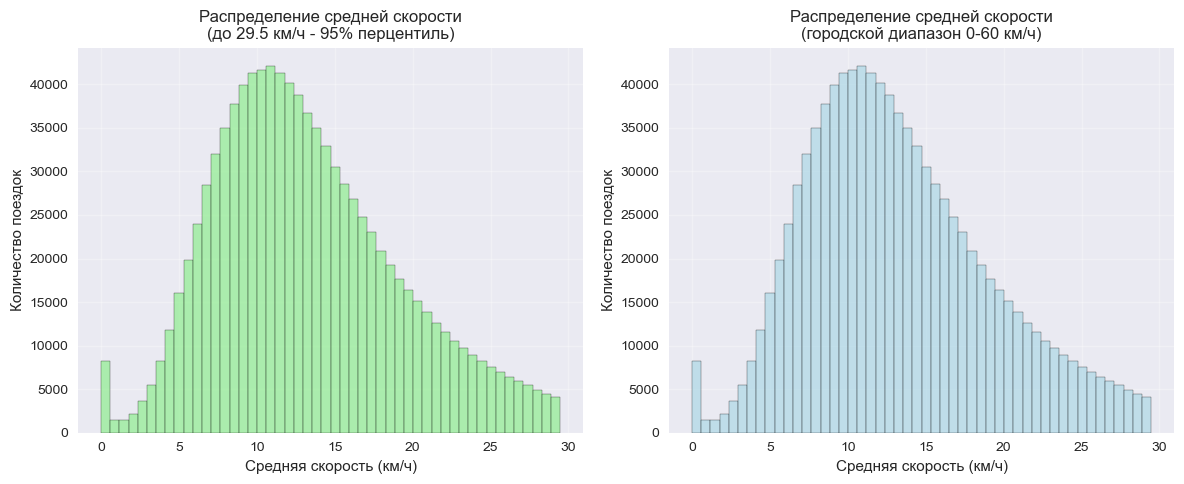


Статистика для разумных скоростей:
Минимальная скорость: 0.00 км/ч
Максимальная скорость: 29.46 км/ч
Средняя скорость: 13.22 км/ч
Медианная скорость: 12.41 км/ч

Анализ аномальных скоростей (> 29.5 км/ч):
Количество аномальных поездок: 51053
Максимальная скорость в аномалиях: 9274.85 км/ч
Средняя продолжительность аномальных поездок: 1031.6 сек
Среднее расстояние аномальных поездок: 10.534 км


In [188]:
# ВАШ КОД ТУТ
# Определяем разумный порог скорости (например, 95-я процентиль)
speed_quantile_95 = train_df['avg_speed'].quantile(0.95)
speed_quantile_99 = train_df['avg_speed'].quantile(0.99)

print(f"95-я процентиль скорости: {speed_quantile_95:.2f} км/ч")
print(f"99-я процентиль скорости: {speed_quantile_99:.2f} км/ч")

# Фильтруем данные для разумных скоростей
reasonable_speed_threshold = speed_quantile_95  # можно использовать 95-ю или 99-ю процентиль
reasonable_speeds_df = train_df[train_df['avg_speed'] <= reasonable_speed_threshold]

print(f"\nИсходное количество поездок: {len(train_df)}")
print(f"Количество поездок с разумными скоростями: {len(reasonable_speeds_df)}")
print(f"Отфильтровано поездок: {len(train_df) - len(reasonable_speeds_df)}")

# Строим гистограмму для разумных скоростей
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(reasonable_speeds_df['avg_speed'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title(f'Распределение средней скорости\n(до {reasonable_speed_threshold:.1f} км/ч - 95% перцентиль)')
plt.xlabel('Средняя скорость (км/ч)')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)

# Дополнительно: гистограмма для наиболее типичных городских скоростей (0-60 км/ч)
plt.subplot(1, 2, 2)
city_speeds = reasonable_speeds_df[reasonable_speeds_df['avg_speed'] <= 60]
plt.hist(city_speeds['avg_speed'], bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.title('Распределение средней скорости\n(городской диапазон 0-60 км/ч)')
plt.xlabel('Средняя скорость (км/ч)')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика для разумных скоростей
print("\nСтатистика для разумных скоростей:")
print(f"Минимальная скорость: {reasonable_speeds_df['avg_speed'].min():.2f} км/ч")
print(f"Максимальная скорость: {reasonable_speeds_df['avg_speed'].max():.2f} км/ч")
print(f"Средняя скорость: {reasonable_speeds_df['avg_speed'].mean():.2f} км/ч")
print(f"Медианная скорость: {reasonable_speeds_df['avg_speed'].median():.2f} км/ч")

# Анализ отфильтрованных аномальных скоростей
anomalous_speeds = train_df[train_df['avg_speed'] > reasonable_speed_threshold]
print(f"\nАнализ аномальных скоростей (> {reasonable_speed_threshold:.1f} км/ч):")
print(f"Количество аномальных поездок: {len(anomalous_speeds)}")
print(f"Максимальная скорость в аномалиях: {anomalous_speeds['avg_speed'].max():.2f} км/ч")
print(f"Средняя продолжительность аномальных поездок: {anomalous_speeds['trip_duration'].mean():.1f} сек")
print(f"Среднее расстояние аномальных поездок: {anomalous_speeds['haversine'].mean():.3f} км")

Для каждой пары (день недели, час суток) посчитайте медиану скоростей. Нарисуйте с помощью `sns.heatmap` график, где по осям будут дни недели и часы, а в качестве значения функции - медиана скорости

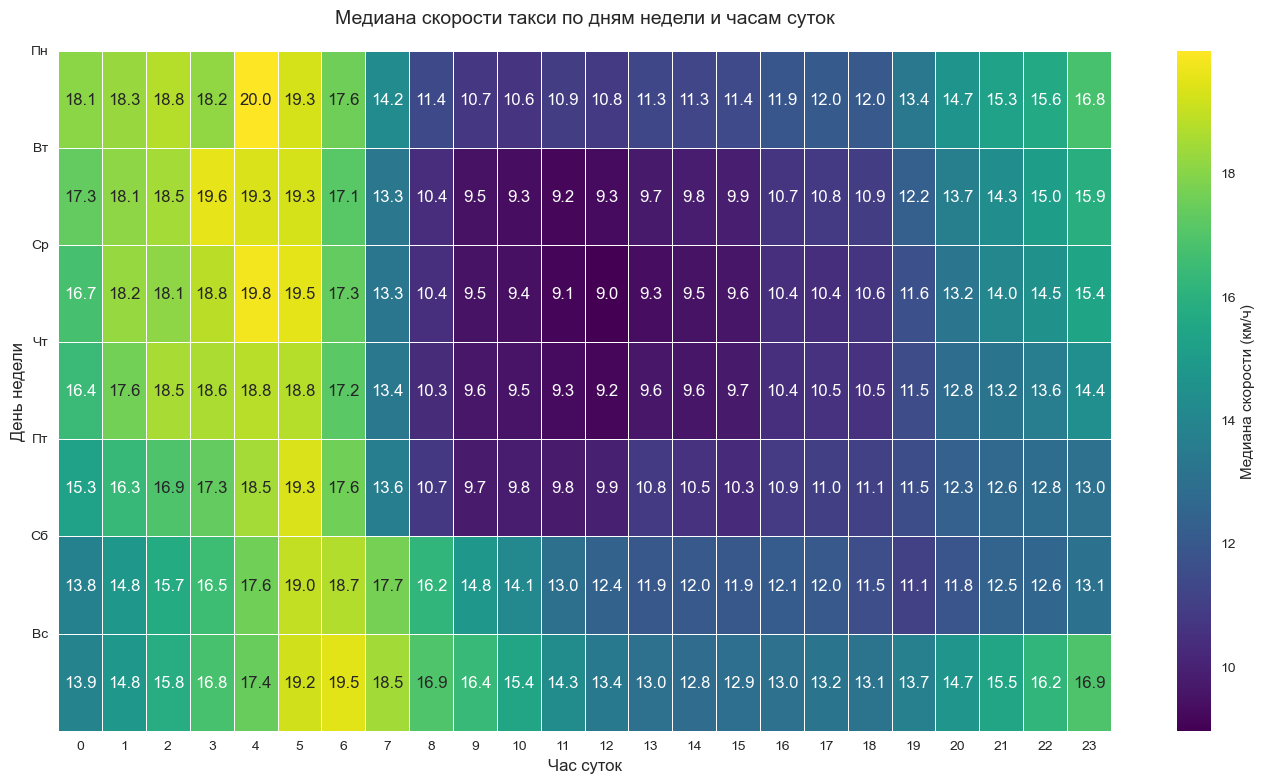

Статистика по тепловой карте:
Минимальная медианная скорость: 9.0 км/ч
Максимальная медианная скорость: 20.0 км/ч
Средняя медианная скорость: 13.8 км/ч

Самый быстрый период: Пн 4:00 - 20.0 км/ч
Самый медленный период: Ср 12:00 - 9.0 км/ч


In [191]:
# ВАШ КОД ТУТ
# Создаем сводную таблицу с медианой скоростей для каждой пары (день недели, час)
speed_pivot = reasonable_speeds_df.pivot_table(
    values='avg_speed',
    index='pickup_weekday',  # день недели (0-6)
    columns='pickup_hour',   # час суток (0-23)
    aggfunc='median'
)

# Названия дней недели для подписей
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# Строим тепловую карту
plt.figure(figsize=(14, 8))
sns.heatmap(speed_pivot, 
            annot=True,           # показывать значения в ячейках
            fmt='.1f',           # формат чисел (1 десятичный знак)
            cmap='viridis',      # цветовая схема
            cbar_kws={'label': 'Медиана скорости (км/ч)'},
            linewidths=0.5,      # линии между ячейками
            linecolor='white')   # цвет линий

plt.title('Медиана скорости такси по дням недели и часам суток', fontsize=14, pad=20)
plt.xlabel('Час суток', fontsize=12)
plt.ylabel('День недели', fontsize=12)

# Настраиваем подписи осей
plt.xticks(rotation=0)
plt.yticks(ticks=range(7), labels=weekday_names, rotation=0)

plt.tight_layout()
plt.show()

# Дополнительная информация
print("Статистика по тепловой карте:")
print(f"Минимальная медианная скорость: {speed_pivot.min().min():.1f} км/ч")
print(f"Максимальная медианная скорость: {speed_pivot.max().max():.1f} км/ч")
print(f"Средняя медианная скорость: {speed_pivot.mean().mean():.1f} км/ч")

# Найдем часы с самой высокой и самой низкой скоростью
max_speed_idx = speed_pivot.stack().idxmax()
min_speed_idx = speed_pivot.stack().idxmin()

print(f"\nСамый быстрый период: {weekday_names[max_speed_idx[0]]} {max_speed_idx[1]}:00 - {speed_pivot.loc[max_speed_idx]:.1f} км/ч")
print(f"Самый медленный период: {weekday_names[min_speed_idx[0]]} {min_speed_idx[1]}:00 - {speed_pivot.loc[min_speed_idx]:.1f} км/ч")

Не забудьте удалить колонку со значением скорости из данных!

**Вопрос**: Почему значение скорости нельзя использовать во время обучения?

скорость содержит информацию о целевой переменной trip_duration

In [201]:
# ВАШ КОД ТУТ
df_with_features = df_with_features.drop('avg_speed', axis=1, errors='ignore')


**Вопрос**: Посмотрите внимательно на график и скажите, в какие моменты времени скорость минимальна; максимальна.

Создайте признаки "поездка совершается в период пробок" и "поездка совершается в период свободных дорог" (естественно, они не должен зависеть от скорости!):

In [204]:
# ВАШ КОД ТУТ
# Создаем признаки пробок и свободных дорог на основе временных паттернов

# Периоды пробок (утренние и вечерние часы пик в рабочие дни)
df_with_features['is_rush_hour_morning'] = ((df_with_features['pickup_weekday'] < 5) &  # пн-пт
                                           (df_with_features['pickup_hour'] >= 7) & 
                                           (df_with_features['pickup_hour'] <= 10)).astype(int)

df_with_features['is_rush_hour_evening'] = ((df_with_features['pickup_weekday'] < 5) &  # пн-пт
                                           (df_with_features['pickup_hour'] >= 16) & 
                                           (df_with_features['pickup_hour'] <= 19)).astype(int)

# Общий признак пробок
df_with_features['is_rush_hour'] = (df_with_features['is_rush_hour_morning'] | 
                                   df_with_features['is_rush_hour_evening']).astype(int)

# Периоды свободных дорог (ночные часы и выходные утро)
df_with_features['is_free_road_night'] = ((df_with_features['pickup_hour'] >= 23) | 
                                         (df_with_features['pickup_hour'] <= 4)).astype(int)

df_with_features['is_free_road_weekend_morning'] = ((df_with_features['pickup_weekday'] >= 5) &  # сб-вс
                                                   (df_with_features['pickup_hour'] >= 5) & 
                                                   (df_with_features['pickup_hour'] <= 7)).astype(int)

# Общий признак свободных дорог
df_with_features['is_free_road'] = (df_with_features['is_free_road_night'] | 
                                   df_with_features['is_free_road_weekend_morning']).astype(int)

# Проверим созданные признаки
print("Статистика созданных признаков:")
print(f"Поездок в утренние часы пик: {df_with_features['is_rush_hour_morning'].sum()}")
print(f"Поездок в вечерние часы пик: {df_with_features['is_rush_hour_evening'].sum()}")
print(f"Всего поездок в часы пик: {df_with_features['is_rush_hour'].sum()}")
print(f"Поездок в ночные часы: {df_with_features['is_free_road_night'].sum()}")
print(f"Поездок в утро выходных: {df_with_features['is_free_road_weekend_morning'].sum()}")
print(f"Всего поездок на свободных дорогах: {df_with_features['is_free_road'].sum()}")

print("\nПервые 10 записей с новыми признаками:")
print(df_with_features[['pickup_datetime', 'pickup_weekday', 'pickup_hour', 
                       'is_rush_hour', 'is_free_road']].head(10))

Статистика созданных признаков:
Поездок в утренние часы пик: 207044
Поездок в вечерние часы пик: 232811
Всего поездок в часы пик: 439855
Поездок в ночные часы: 226263
Поездок в утро выходных: 15214
Всего поездок на свободных дорогах: 241477

Первые 10 записей с новыми признаками:
      pickup_datetime  pickup_weekday  pickup_hour  is_rush_hour  is_free_road
0 2016-03-14 17:24:55               0           17             1             0
1 2016-06-12 00:43:35               6            0             0             1
2 2016-01-19 11:35:24               1           11             0             0
3 2016-04-06 19:32:31               2           19             1             0
4 2016-03-26 13:30:55               5           13             0             0
5 2016-01-30 22:01:40               5           22             0             0
6 2016-06-17 22:34:59               4           22             0             0
7 2016-05-21 07:54:58               5            7             0             1
8 2016-0

**Задание 7**. Для каждого из замеченных вами выше 2-3 пунктов добавьте в выборку по два признака: 
- началась ли поездка в этом пункте
- закончилась ли поездка в этом пункте

Как вы думаете, почему эти признаки могут быть полезны?

In [207]:
# ВАШ КОД ТУТ
# Определяем популярные пункты на основе частоты поездок
top_pickup_locations = df_with_features.groupby(['pickup_latitude', 'pickup_longitude']).size().nlargest(3).index
top_dropoff_locations = df_with_features.groupby(['dropoff_latitude', 'dropoff_longitude']).size().nlargest(3).index

print("Топ-3 популярных пункта посадки:")
for i, (lat, lon) in enumerate(top_pickup_locations, 1):
    count = df_with_features[(df_with_features['pickup_latitude'] == lat) & 
                           (df_with_features['pickup_longitude'] == lon)].shape[0]
    print(f"{i}. Широта: {lat:.4f}, Долгота: {lon:.4f} - {count} поездок")

print("\nТоп-3 популярных пункта высадки:")
for i, (lat, lon) in enumerate(top_dropoff_locations, 1):
    count = df_with_features[(df_with_features['dropoff_latitude'] == lat) & 
                           (df_with_features['dropoff_longitude'] == lon)].shape[0]
    print(f"{i}. Широта: {lat:.4f}, Долгота: {lon:.4f} - {count} поездок")

# Создаем признаки для топ-3 пунктов посадки
for i, (lat, lon) in enumerate(top_pickup_locations, 1):
    df_with_features[f'starts_at_popular_pickup_{i}'] = (
        (df_with_features['pickup_latitude'] == lat) & 
        (df_with_features['pickup_longitude'] == lon)
    ).astype(int)

# Создаем признаки для топ-3 пунктов высадки
for i, (lat, lon) in enumerate(top_dropoff_locations, 1):
    df_with_features[f'ends_at_popular_dropoff_{i}'] = (
        (df_with_features['dropoff_latitude'] == lat) & 
        (df_with_features['dropoff_longitude'] == lon)
    ).astype(int)

# Проверяем созданные признаки
print(f"\nСтатистика созданных признаков:")
for i in range(1, 4):
    pickup_col = f'starts_at_popular_pickup_{i}'
    dropoff_col = f'ends_at_popular_dropoff_{i}'
    print(f"{pickup_col}: {df_with_features[pickup_col].sum()} поездок")
    print(f"{dropoff_col}: {df_with_features[dropoff_col].sum()} поездок")

# Дополнительно: создаем общие признаки популярных локаций
df_with_features['starts_at_any_popular_pickup'] = (
    df_with_features[[f'starts_at_popular_pickup_{i}' for i in range(1, 4)]].max(axis=1)
)
df_with_features['ends_at_any_popular_dropoff'] = (
    df_with_features[[f'ends_at_popular_dropoff_{i}' for i in range(1, 4)]].max(axis=1)
)

print(f"\nОбщие признаки:")
print(f"Начинается в любом популярном пункте: {df_with_features['starts_at_any_popular_pickup'].sum()} поездок")
print(f"Заканчивается в любом популярном пункте: {df_with_features['ends_at_any_popular_dropoff'].sum()} поездок")

Топ-3 популярных пункта посадки:
1. Широта: 40.8210, Долгота: -73.9547 - 39 поездок
2. Широта: 40.7738, Долгота: -73.8709 - 15 поездок
3. Широта: 40.7737, Долгота: -73.8709 - 14 поездок

Топ-3 популярных пункта высадки:
1. Широта: 40.8210, Долгота: -73.9547 - 39 поездок
2. Широта: 40.7504, Долгота: -73.9947 - 10 поездок
3. Широта: 40.7606, Долгота: -74.0028 - 10 поездок

Статистика созданных признаков:
starts_at_popular_pickup_1: 39 поездок
ends_at_popular_dropoff_1: 39 поездок
starts_at_popular_pickup_2: 15 поездок
ends_at_popular_dropoff_2: 10 поездок
starts_at_popular_pickup_3: 14 поездок
ends_at_popular_dropoff_3: 10 поездок

Общие признаки:
Начинается в любом популярном пункте: 68 поездок
Заканчивается в любом популярном пункте: 59 поездок


Для каждого из созданных признаков нарисуйте "ящик с усами" (`sns.boxplot`) распределения логарифма времени поездки

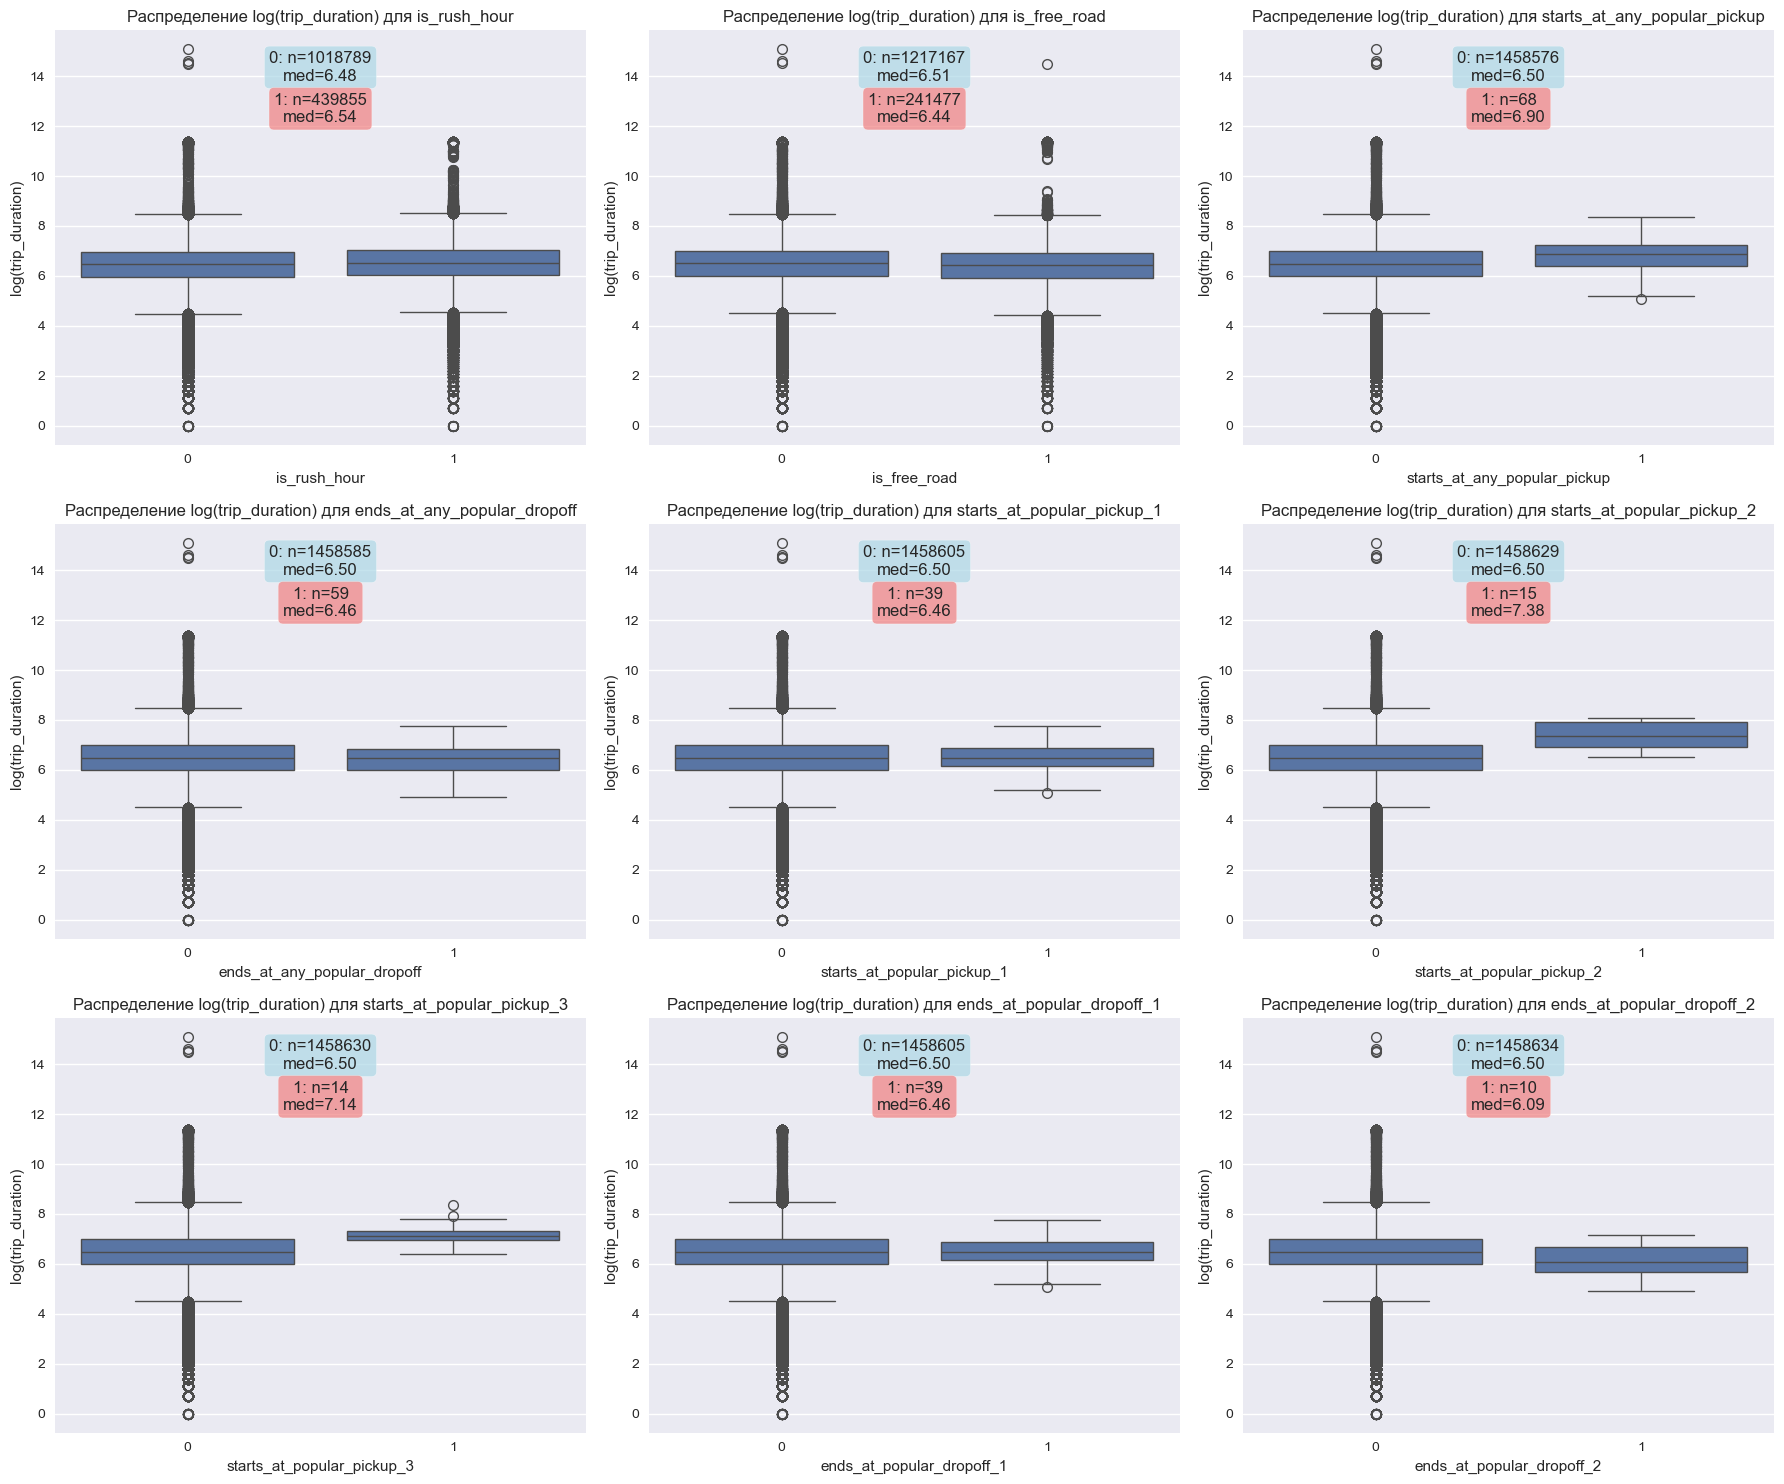

Статистика медианного log(trip_duration) по признакам:
is_rush_hour                        | 0:  6.535 (n=439855) | 1:  6.479 (n=1018789) | diff:  0.057
is_free_road                        | 0:  6.441 (n=241477) | 1:  6.507 (n=1217167) | diff: -0.066
starts_at_any_popular_pickup        | 0:  6.896 (n=    68) | 1:  6.495 (n=1458576) | diff:  0.401
ends_at_any_popular_dropoff         | 0:  6.461 (n=    59) | 1:  6.495 (n=1458585) | diff: -0.034
starts_at_popular_pickup_1          | 0:  6.463 (n=    39) | 1:  6.495 (n=1458605) | diff: -0.032
starts_at_popular_pickup_2          | 0:  7.376 (n=    15) | 1:  6.495 (n=1458629) | diff:  0.881
starts_at_popular_pickup_3          | 0:  7.136 (n=    14) | 1:  6.495 (n=1458630) | diff:  0.641
ends_at_popular_dropoff_1           | 0:  6.463 (n=    39) | 1:  6.495 (n=1458605) | diff: -0.032
ends_at_popular_dropoff_2           | 0:  6.093 (n=    10) | 1:  6.495 (n=1458634) | diff: -0.402
ends_at_popular_dropoff_3           | 0:  6.465 (n=    10) | 1:

In [210]:
# ВАШ КОД ТУТ
# Создаем логарифмированный таргет для визуализации
df_with_features['log_trip_duration'] = np.log(df_with_features['trip_duration'])

# Список созданных признаков для визуализации
location_features = [
    'is_rush_hour', 'is_free_road',
    'starts_at_any_popular_pickup', 'ends_at_any_popular_dropoff'
] + [f'starts_at_popular_pickup_{i}' for i in range(1, 4)] + [f'ends_at_popular_dropoff_{i}' for i in range(1, 4)]

# Строим boxplot для каждого признака
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, feature in enumerate(location_features[:9]):  # первые 9 признаков
    if feature in df_with_features.columns:
        sns.boxplot(data=df_with_features, x=feature, y='log_trip_duration', ax=axes[i])
        axes[i].set_title(f'Распределение log(trip_duration) для {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('log(trip_duration)')
        
        # Добавляем аннотации со статистикой
        stats_0 = df_with_features[df_with_features[feature] == 0]['log_trip_duration'].describe()
        stats_1 = df_with_features[df_with_features[feature] == 1]['log_trip_duration'].describe()
        
        axes[i].text(0.5, 0.95, f'0: n={stats_0["count"]:.0f}\nmed={stats_0["50%"]:.2f}', 
                    transform=axes[i].transAxes, ha='center', va='top', 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
        axes[i].text(0.5, 0.85, f'1: n={stats_1["count"]:.0f}\nmed={stats_1["50%"]:.2f}', 
                    transform=axes[i].transAxes, ha='center', va='top', 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

# Убираем лишние subplots
for i in range(len(location_features), 9):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Дополнительная статистика по всем признакам
print("Статистика медианного log(trip_duration) по признакам:")
for feature in location_features:
    if feature in df_with_features.columns:
        median_0 = df_with_features[df_with_features[feature] == 0]['log_trip_duration'].median()
        median_1 = df_with_features[df_with_features[feature] == 1]['log_trip_duration'].median()
        count_0 = (df_with_features[feature] == 0).sum()
        count_1 = (df_with_features[feature] == 1).sum()
        diff = median_1 - median_0
        
        print(f"{feature:35} | 0: {median_1:6.3f} (n={count_1:6d}) | 1: {median_0:6.3f} (n={count_0:6d}) | diff: {diff:6.3f}")

**Вопрос**: судя по графикам, как вы думаете, хорошими ли получились эти признаки?

<img src="https://www.dropbox.com/s/xson9nukz5hba7c/map.png?raw=1" align="right" width="20%" style="margin-left: 20px; margin-bottom: 20px">

**Задание 8**. Сейчас мы почти что не используем сами значения координат. На это есть несколько причин: по отдельности рассматривать широту и долготу не имеет особого смысла, стоит рассматривать их вместе. Во-вторых, понятно, что зависимость между нашим таргетом и координатами не линейная. Чтобы как-то использовать координаты, можно прибегнуть к следующему трюку: обрамим область с наибольшим количеством поездок прямоугольником (как на рисунке). Разобьем этот прямоугольник на ячейки. Каждой точке сопоставим номер ее ячейки, а тем точкам, что не попали ни в одну из ячеек, сопоставим значение -1.

Напишите трансформер, который сначала разбивает показанную на рисунке область на ячейки, а затем создает два признака: номер ячейки, в которой началась поездка, и номер ячейки, в которой закончилась поездка. Количество строк и столбцов выберите самостоятельно.

Обратите внимание, что все вычисления должны быть векторизованными, трансформер не должен модифицировать передаваемую ему выборку inplace, а все необходимые статистики (если они вдруг нужны) нужно считать только по обучающей выборке в методе `fit`:

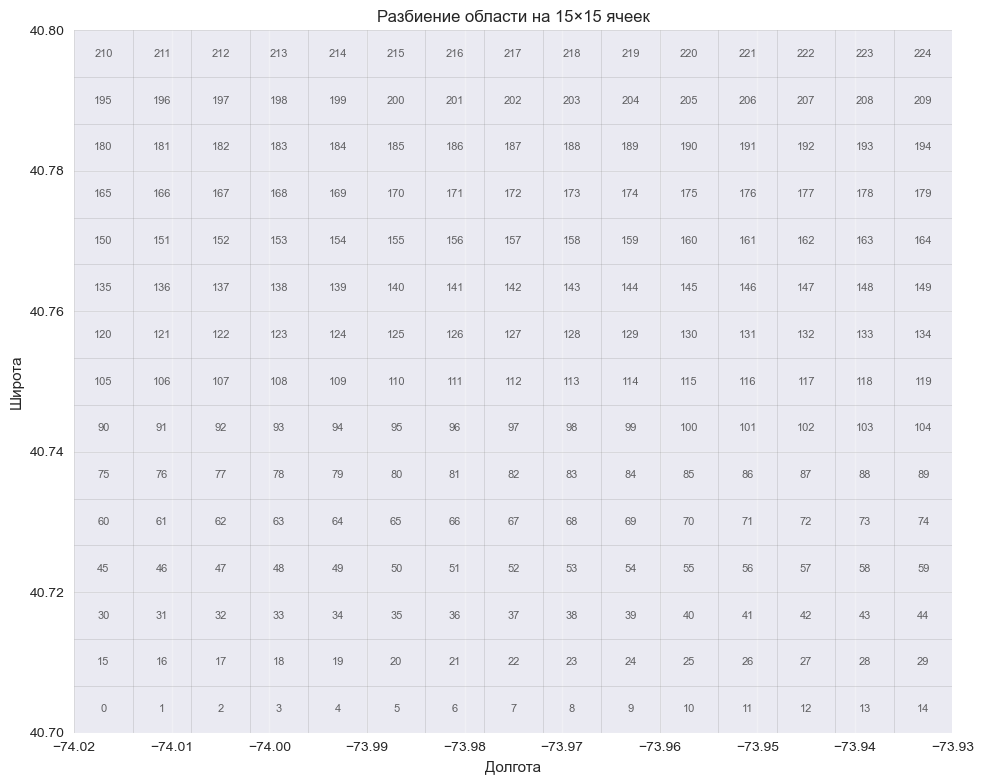

Статистика по ячейкам:
Всего ячеек: 225
Уникальных ячеек посадки: 204
Уникальных ячеек высадки: 212
Поездок вне области: посадка - 127116, высадка - 191812

Первые 5 записей:
   pickup_latitude  pickup_longitude  pickup_cell  dropoff_latitude  \
0        40.767937        -73.982155          156         40.765602   
1        40.738564        -73.980415           81         40.731152   
2        40.763939        -73.979027          141         40.710087   
3        40.719971        -74.010040           31         40.706718   
4        40.793209        -73.973053          202         40.782520   

   dropoff_longitude  dropoff_cell  
0         -73.964630           144  
1         -73.999481            63  
2         -74.005333            17  
3         -74.012268            16  
4         -73.972923           187  


In [213]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import matplotlib.pyplot as plt

class MapGridTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_rows=10, n_cols=10):
        """
        Трансформер для разбиения области на ячейки и присвоения номеров ячеек точкам.
        
        Parameters:
        n_rows (int): количество строк (широта)
        n_cols (int): количество столбцов (долгота)
        """
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.lat_min = 40.70
        self.lat_max = 40.80
        self.lon_min = -74.02
        self.lon_max = -73.93
        
    def show_map(self):
        """Визуализация ячеек на карте."""
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Рисуем границы ячеек
        lat_bins = np.linspace(self.lat_min, self.lat_max, self.n_rows + 1)
        lon_bins = np.linspace(self.lon_min, self.lon_max, self.n_cols + 1)
        
        for lat in lat_bins:
            ax.axhline(lat, color='gray', alpha=0.3, linewidth=0.5)
        for lon in lon_bins:
            ax.axvline(lon, color='gray', alpha=0.3, linewidth=0.5)
        
        # Подписи осей
        ax.set_xlabel('Долгота')
        ax.set_ylabel('Широта')
        ax.set_title(f'Разбиение области на {self.n_rows}×{self.n_cols} ячеек')
        
        # Область карты
        ax.set_xlim(self.lon_min, self.lon_max)
        ax.set_ylim(self.lat_min, self.lat_max)
        
        # Добавляем номера ячеек
        for i in range(self.n_rows):
            for j in range(self.n_cols):
                cell_lat = (lat_bins[i] + lat_bins[i+1]) / 2
                cell_lon = (lon_bins[j] + lon_bins[j+1]) / 2
                cell_num = i * self.n_cols + j
                ax.text(cell_lon, cell_lat, str(cell_num), 
                       ha='center', va='center', fontsize=8, alpha=0.7)
        
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def fit(self, X=None, y=None):
        """
        Вычисляет границы области (в данном случае фиксированные).
        Может быть расширен для автоматического определения границ по данным.
        """
        # Границы зафиксированы как на рисунке (Манхэттен и окрестности)
        # Можно раскомментировать для автоматического определения:
        # if X is not None:
        #     self.lat_min = X['pickup_latitude'].quantile(0.01)
        #     self.lat_max = X['pickup_latitude'].quantile(0.99)
        #     self.lon_min = X['pickup_longitude'].quantile(0.01)
        #     self.lon_max = X['pickup_longitude'].quantile(0.99)
        
        return self

    def transform(self, X, y=None):
        """
        Присваивает номера ячеек точкам начала и окончания поездки.
        
        Parameters:
        X (pd.DataFrame): данные для трансформации
        
        Returns:
        pd.DataFrame: копия данных с добавленными колонками pickup_cell и dropoff_cell
        """
        X = X.copy()
        
        # Создаем ячейки для широты и долготы
        lat_bins = np.linspace(self.lat_min, self.lat_max, self.n_rows + 1)
        lon_bins = np.linspace(self.lon_min, self.lon_max, self.n_cols + 1)
        
        # Функция для определения номера ячейки (векторизованная)
        def get_cell_number(lat, lon):
            # Проверяем, попадает ли точка в область
            in_area = ((lat >= self.lat_min) & (lat <= self.lat_max) & 
                      (lon >= self.lon_min) & (lon <= self.lon_max))
            
            # Для точек в области вычисляем номер ячейки
            lat_idx = np.digitize(lat, lat_bins) - 1
            lon_idx = np.digitize(lon, lon_bins) - 1
            
            # Объединяем индексы в один номер ячейки
            cell_number = lat_idx * self.n_cols + lon_idx
            
            # Для точек вне области ставим -1
            cell_number = np.where(in_area, cell_number, -1)
            
            # Корректируем граничные случаи (точки на правой/верхней границе)
            cell_number = np.where(lat_idx >= self.n_rows, -1, cell_number)
            cell_number = np.where(lon_idx >= self.n_cols, -1, cell_number)
            
            return cell_number
        
        # Применяем к точкам начала и окончания поездки
        X['pickup_cell'] = get_cell_number(
            X['pickup_latitude'].values, 
            X['pickup_longitude'].values
        )
        
        X['dropoff_cell'] = get_cell_number(
            X['dropoff_latitude'].values, 
            X['dropoff_longitude'].values
        )
        
        return X

# Пример использования
transformer = MapGridTransformer(n_rows=15, n_cols=15)

# Фитируем (в данном случае просто возвращает self)
transformer.fit()

# Показываем карту ячеек
transformer.show_map()

# Трансформируем данные
df_with_cells = transformer.transform(df_with_features)

# Проверяем результат
print("Статистика по ячейкам:")
print(f"Всего ячеек: {15 * 15}")
print(f"Уникальных ячеек посадки: {df_with_cells['pickup_cell'].nunique()}")
print(f"Уникальных ячеек высадки: {df_with_cells['dropoff_cell'].nunique()}")
print(f"Поездок вне области: посадка - {(df_with_cells['pickup_cell'] == -1).sum()}, "
      f"высадка - {(df_with_cells['dropoff_cell'] == -1).sum()}")

print("\nПервые 5 записей:")
print(df_with_cells[['pickup_latitude', 'pickup_longitude', 'pickup_cell', 
                    'dropoff_latitude', 'dropoff_longitude', 'dropoff_cell']].head())

## Часть 3. Изучаем оставшиеся признаки

**Задание 9**. У нас осталось еще 3 признака, которые мы не исследовали: `vendor_id`, `passenger_count` и `store_and_fwd_flag`.

**Вопрос**: Подумайте, почему каждый из этих признаков может быть потенциально полезным.

Посчитайте, сколько есть уникальных значений у каждого из этих признаков:

Уникальные значения для каждого признака:

vendor_id:
  Уникальных значений: 2
  Уникальные значения: [1, 2]
  Распределение:
    2: 780302 поездок (53.5%)
    1: 678342 поездок (46.5%)

passenger_count:
  Уникальных значений: 10
  Уникальные значения: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Распределение:
    1: 1033540 поездок (70.9%)
    2: 210318 поездок (14.4%)
    5: 78088 поездок (5.4%)
    3: 59896 поездок (4.1%)
    6: 48333 поездок (3.3%)

store_and_fwd_flag:
  Уникальных значений: 2
  Уникальные значения: ['N', 'Y']
  Распределение:
    N: 1450599 поездок (99.4%)
    Y: 8045 поездок (0.6%)

ПОТЕНЦИАЛЬНАЯ ПОЛЕЗНОСТЬ ПРИЗНАКОВ:

1. vendor_id (ID вендора такси):
   - Разные вендоры могут использовать разные тарифы/алгоритмы
   - Разное качество обслуживания и состояние автомобилей
   - Разные стратегии работы водителей
   - Могут обслуживать разные районы города

2. passenger_count (количество пассажиров):
   - Влияет на время посадки/высадки
   - Может влиять на выбор маршрута (больш

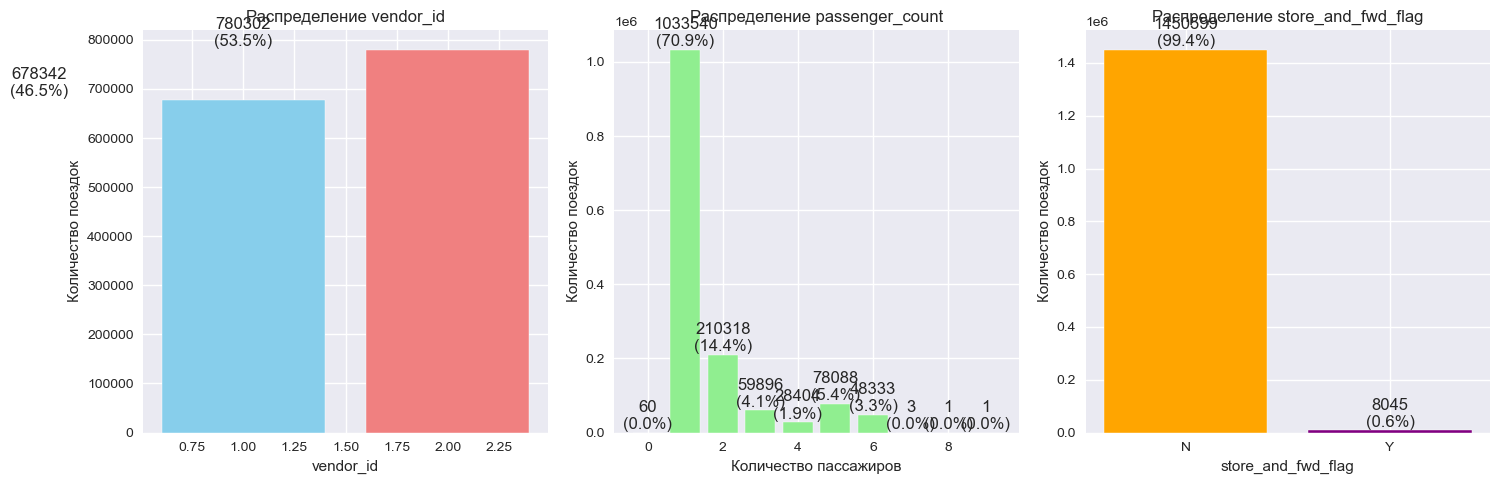


АНАЛИЗ СВЯЗИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:

vendor_id vs log_trip_duration:
            mean  median   count
vendor_id                       
1          6.448   6.489  678342
2          6.479   6.501  780302

passenger_count vs log_trip_duration:
                  mean  median    count
passenger_count                        
0                3.538   3.018       60
1                6.448   6.483  1033540
2                6.514   6.535   210318
3                6.515   6.534    59896
4                6.531   6.548    28404
5                6.487   6.507    78088
6                6.477   6.495    48333
7                2.957   2.944        3
8                4.644   4.644        1
9                6.328   6.328        1

store_and_fwd_flag vs log_trip_duration:
                     mean  median    count
store_and_fwd_flag                        
N                   6.464   6.495  1450599
Y                   6.627   6.700     8045


In [216]:
# ВАШ КОД ТУТ
# Исследуем оставшиеся признаки
remaining_features = ['vendor_id', 'passenger_count', 'store_and_fwd_flag']

print("Уникальные значения для каждого признака:")
for feature in remaining_features:
    unique_values = df_with_features[feature].unique()
    unique_count = df_with_features[feature].nunique()
    value_counts = df_with_features[feature].value_counts().head()
    
    print(f"\n{feature}:")
    print(f"  Уникальных значений: {unique_count}")
    print(f"  Уникальные значения: {sorted(unique_values)}")
    print(f"  Распределение:")
    for value, count in value_counts.items():
        print(f"    {value}: {count} поездок ({count/len(df_with_features)*100:.1f}%)")

# Дополнительный анализ
print("\n" + "="*50)
print("ПОТЕНЦИАЛЬНАЯ ПОЛЕЗНОСТЬ ПРИЗНАКОВ:")
print("="*50)

print("\n1. vendor_id (ID вендора такси):")
print("   - Разные вендоры могут использовать разные тарифы/алгоритмы")
print("   - Разное качество обслуживания и состояние автомобилей")
print("   - Разные стратегии работы водителей")
print("   - Могут обслуживать разные районы города")

print("\n2. passenger_count (количество пассажиров):")
print("   - Влияет на время посадки/высадки")
print("   - Может влиять на выбор маршрута (большие группы)")
print("   - Связано с типом поездки (одиночная/групповая)")
print("   - Может коррелировать с временем суток/днем недели")

print("\n3. store_and_fwd_flag (флаг сохранения данных):")
print("   - Указывает на качество связи/покрытие сети")
print("   - Может быть индикатором технических проблем")
print("   - Может коррелировать с определенными районами")
print("   - Может влиять на точность данных о времени поездки")

# Визуализируем распределение этих признаков
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# vendor_id
vendor_counts = df_with_features['vendor_id'].value_counts().sort_index()
axes[0].bar(vendor_counts.index, vendor_counts.values, color=['skyblue', 'lightcoral'])
axes[0].set_title('Распределение vendor_id')
axes[0].set_xlabel('vendor_id')
axes[0].set_ylabel('Количество поездок')
for i, v in enumerate(vendor_counts.values):
    axes[0].text(i, v + 1000, f'{v}\n({v/len(df_with_features)*100:.1f}%)', 
                ha='center', va='bottom')

# passenger_count
passenger_counts = df_with_features['passenger_count'].value_counts().sort_index()
axes[1].bar(passenger_counts.index, passenger_counts.values, color='lightgreen')
axes[1].set_title('Распределение passenger_count')
axes[1].set_xlabel('Количество пассажиров')
axes[1].set_ylabel('Количество поездок')
for i, v in enumerate(passenger_counts.values):
    axes[1].text(passenger_counts.index[i], v + 1000, f'{v}\n({v/len(df_with_features)*100:.1f}%)', 
                ha='center', va='bottom')

# store_and_fwd_flag
store_counts = df_with_features['store_and_fwd_flag'].value_counts()
axes[2].bar(store_counts.index, store_counts.values, color=['orange', 'purple'])
axes[2].set_title('Распределение store_and_fwd_flag')
axes[2].set_xlabel('store_and_fwd_flag')
axes[2].set_ylabel('Количество поездок')
for i, v in enumerate(store_counts.values):
    axes[2].text(i, v + 1000, f'{v}\n({v/len(df_with_features)*100:.1f}%)', 
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Анализ связи с целевой переменной
print("\n" + "="*50)
print("АНАЛИЗ СВЯЗИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
print("="*50)

for feature in remaining_features:
    print(f"\n{feature} vs log_trip_duration:")
    grouped = df_with_features.groupby(feature)['log_trip_duration'].agg(['mean', 'median', 'count'])
    print(grouped.round(3))

Постройте "ящики с усами" распределений логарифма времени поездки в зависимости от значений каждого из признаков

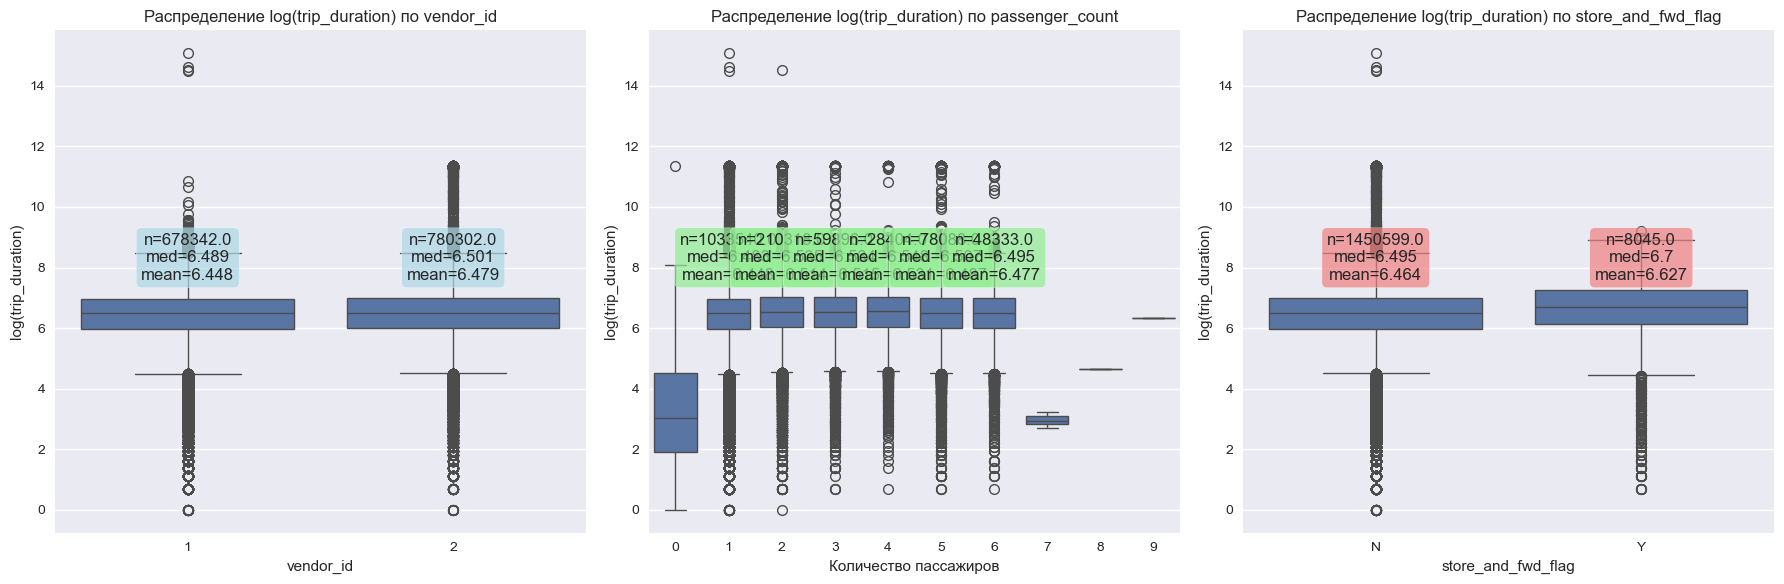

ДЕТАЛЬНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ:

vendor_id:
----------------------------------------
            count   mean  median    std  min     max  percent
vendor_id                                                    
1          678342  6.448   6.489  0.793  0.0  15.076     46.5
2          780302  6.479   6.501  0.805  0.0  11.367     53.5
Разница медиан: 0.012
❌ НЕЗНАЧИТЕЛЬНЫЕ РАЗЛИЧИЯ между группами

passenger_count:
----------------------------------------
                   count   mean  median    std    min     max  percent
passenger_count                                                       
0                     60  3.538   3.018  2.338  0.000  11.361      0.0
1                1033540  6.448   6.483  0.803  0.000  15.076     70.9
2                 210318  6.514   6.535  0.785  0.000  14.533     14.4
3                  59896  6.515   6.534  0.777  0.693  11.366      4.1
4                  28404  6.531   6.548  0.786  0.693  11.366      1.9
5                  78088  6.487   6.507  0.798 

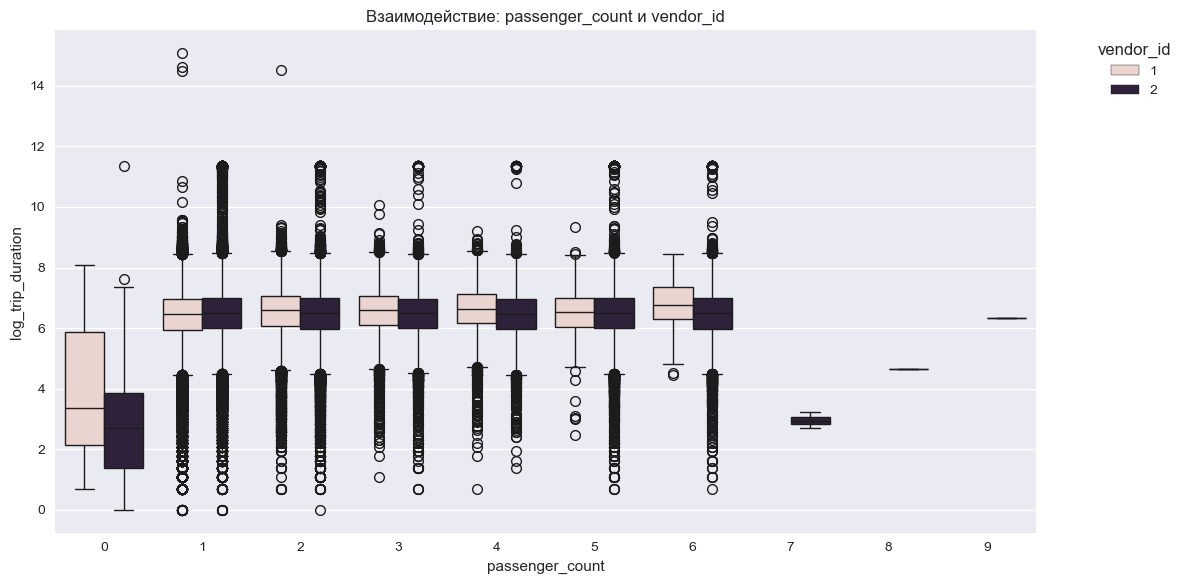

In [219]:
# ВАШ КОД ТУТ
# Строим boxplot'ы для каждого признака
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# vendor_id
sns.boxplot(data=df_with_features, x='vendor_id', y='log_trip_duration', ax=axes[0])
axes[0].set_title('Распределение log(trip_duration) по vendor_id')
axes[0].set_xlabel('vendor_id')
axes[0].set_ylabel('log(trip_duration)')

# Добавляем статистику для vendor_id
vendor_stats = df_with_features.groupby('vendor_id')['log_trip_duration'].agg(['count', 'median', 'mean']).round(3)
for i, (vendor, stats) in enumerate(vendor_stats.iterrows()):
    axes[0].text(i, 7.5, f'n={stats["count"]}\nmed={stats["median"]}\nmean={stats["mean"]}', 
                ha='center', va='bottom', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

# passenger_count
sns.boxplot(data=df_with_features, x='passenger_count', y='log_trip_duration', ax=axes[1])
axes[1].set_title('Распределение log(trip_duration) по passenger_count')
axes[1].set_xlabel('Количество пассажиров')
axes[1].set_ylabel('log(trip_duration)')

# Добавляем статистику для passenger_count
passenger_stats = df_with_features.groupby('passenger_count')['log_trip_duration'].agg(['count', 'median', 'mean']).round(3)
for i, (passengers, stats) in enumerate(passenger_stats.iterrows()):
    if stats['count'] > 100:  # только для значимых групп
        axes[1].text(i, 7.5, f'n={stats["count"]}\nmed={stats["median"]}\nmean={stats["mean"]}', 
                    ha='center', va='bottom', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

# store_and_fwd_flag
sns.boxplot(data=df_with_features, x='store_and_fwd_flag', y='log_trip_duration', ax=axes[2])
axes[2].set_title('Распределение log(trip_duration) по store_and_fwd_flag')
axes[2].set_xlabel('store_and_fwd_flag')
axes[2].set_ylabel('log(trip_duration)')

# Добавляем статистику для store_and_fwd_flag
store_stats = df_with_features.groupby('store_and_fwd_flag')['log_trip_duration'].agg(['count', 'median', 'mean']).round(3)
for i, (store_flag, stats) in enumerate(store_stats.iterrows()):
    axes[2].text(i, 7.5, f'n={stats["count"]}\nmed={stats["median"]}\nmean={stats["mean"]}', 
                ha='center', va='bottom', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

plt.tight_layout()
plt.show()

# Детальный статистический анализ
print("ДЕТАЛЬНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ:")
print("="*60)

for feature in remaining_features:
    print(f"\n{feature}:")
    print("-" * 40)
    
    # Группируем по признаку и вычисляем статистики
    grouped = df_with_features.groupby(feature)['log_trip_duration'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(3)
    
    # Добавляем проценты
    grouped['percent'] = (grouped['count'] / len(df_with_features) * 100).round(1)
    
    print(grouped)
    
    # Проверяем статистическую значимость различий (простая эвристика)
    if len(grouped) > 1:
        max_median = grouped['median'].max()
        min_median = grouped['median'].min()
        diff = max_median - min_median
        print(f"Разница медиан: {diff:.3f}")
        
        if diff > 0.1:
            print("✅ ЗНАЧИМЫЕ РАЗЛИЧИЯ между группами")
        elif diff > 0.05:
            print("⚠️  УМЕРЕННЫЕ РАЗЛИЧИЯ между группами")
        else:
            print("❌ НЕЗНАЧИТЕЛЬНЫЕ РАЗЛИЧИЯ между группами")

# Дополнительный анализ: взаимодействие признаков
print("\n" + "="*60)
print("АНАЛИЗ ВЗАИМОДЕЙСТВИЯ ПРИЗНАКОВ:")
print("="*60)

# vendor_id и passenger_count
print("\nСовместное распределение vendor_id и passenger_count:")
cross_tab = pd.crosstab(df_with_features['vendor_id'], df_with_features['passenger_count'])
print(cross_tab)

# Визуализация взаимодействия vendor_id и passenger_count
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_with_features, x='passenger_count', y='log_trip_duration', hue='vendor_id')
plt.title('Взаимодействие: passenger_count и vendor_id')
plt.legend(title='vendor_id', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Переведите признаки `vendor_id` и `store_and_fwd_flag` в значения $\{0;1\}$

In [222]:
# ВАШ КОД ТУТ
# Преобразуем vendor_id в {0, 1}
# Предполагаем, что vendor_id имеет значения 1 и 2
df_with_features['vendor_id_binary'] = (df_with_features['vendor_id'] - 1).astype(int)

# Преобразуем store_and_fwd_flag в {0, 1}
# 'N' -> 0, 'Y' -> 1
df_with_features['store_and_fwd_flag_binary'] = (df_with_features['store_and_fwd_flag'] == 'Y').astype(int)

# Проверяем преобразование
print("Проверка преобразования признаков:")
print("\nvendor_id -> vendor_id_binary:")
print(df_with_features[['vendor_id', 'vendor_id_binary']].value_counts().sort_index())

print("\nstore_and_fwd_flag -> store_and_fwd_flag_binary:")
print(df_with_features[['store_and_fwd_flag', 'store_and_fwd_flag_binary']].value_counts().sort_index())

# Убедимся, что значения действительно в {0, 1}
print(f"\nУникальные значения vendor_id_binary: {sorted(df_with_features['vendor_id_binary'].unique())}")
print(f"Уникальные значения store_and_fwd_flag_binary: {sorted(df_with_features['store_and_fwd_flag_binary'].unique())}")

# Проверим распределение
print(f"\nРаспределение vendor_id_binary:")
print(df_with_features['vendor_id_binary'].value_counts().sort_index())
print(f"\nРаспределение store_and_fwd_flag_binary:")
print(df_with_features['store_and_fwd_flag_binary'].value_counts().sort_index())

# Удалим исходные колонки, если нужно
# df_with_features = df_with_features.drop(['vendor_id', 'store_and_fwd_flag'], axis=1)

print("\nПервые 5 записей с преобразованными признаками:")
print(df_with_features[['vendor_id', 'vendor_id_binary', 'store_and_fwd_flag', 'store_and_fwd_flag_binary']].head(10))

Проверка преобразования признаков:

vendor_id -> vendor_id_binary:
vendor_id  vendor_id_binary
1          0                   678342
2          1                   780302
Name: count, dtype: int64

store_and_fwd_flag -> store_and_fwd_flag_binary:
store_and_fwd_flag  store_and_fwd_flag_binary
N                   0                            1450599
Y                   1                               8045
Name: count, dtype: int64

Уникальные значения vendor_id_binary: [0, 1]
Уникальные значения store_and_fwd_flag_binary: [0, 1]

Распределение vendor_id_binary:
vendor_id_binary
0    678342
1    780302
Name: count, dtype: int64

Распределение store_and_fwd_flag_binary:
store_and_fwd_flag_binary
0    1450599
1       8045
Name: count, dtype: int64

Первые 5 записей с преобразованными признаками:
   vendor_id  vendor_id_binary store_and_fwd_flag  store_and_fwd_flag_binary
0          2                 1                  N                          0
1          1                 0              

**Вопрос**: Основываясь на графиках выше, как вы думаете, будут ли эти признаки сильными?

## Часть 4. Улучшаем данные

**Задание 10**. В наших данных есть нетипичные объекты (выбросы, или outliers): с аномально маленьким времени поездки, с очень большим пройденным расстоянием или очень большими остатками регрессии. В этом задании предлагается исключить такие объекты из обучающей выборки. Для этого нарисуйте гистограммы распределения упомянутых выше величин, выберите объекты, которые можно назвать выбросами, и очистите __обучающую выборку__ от них.

Отметим, что хотя эти объекты и выглядят как выбросы, в тестовой выборке тоже скорее всего будут объекты с такими же странными значениями целевой переменной и/или признаков. Поэтому, возможно, чистка обучающей выборки приведёт к ухудшению качества на тесте. Тем не менее, всё равно лучше удалять выбросы из обучения, чтобы модель получалась более разумной и интерпретируемой.

Исходный размер обучающей выборки: 1021050
Размер тестовой выборки: 437594


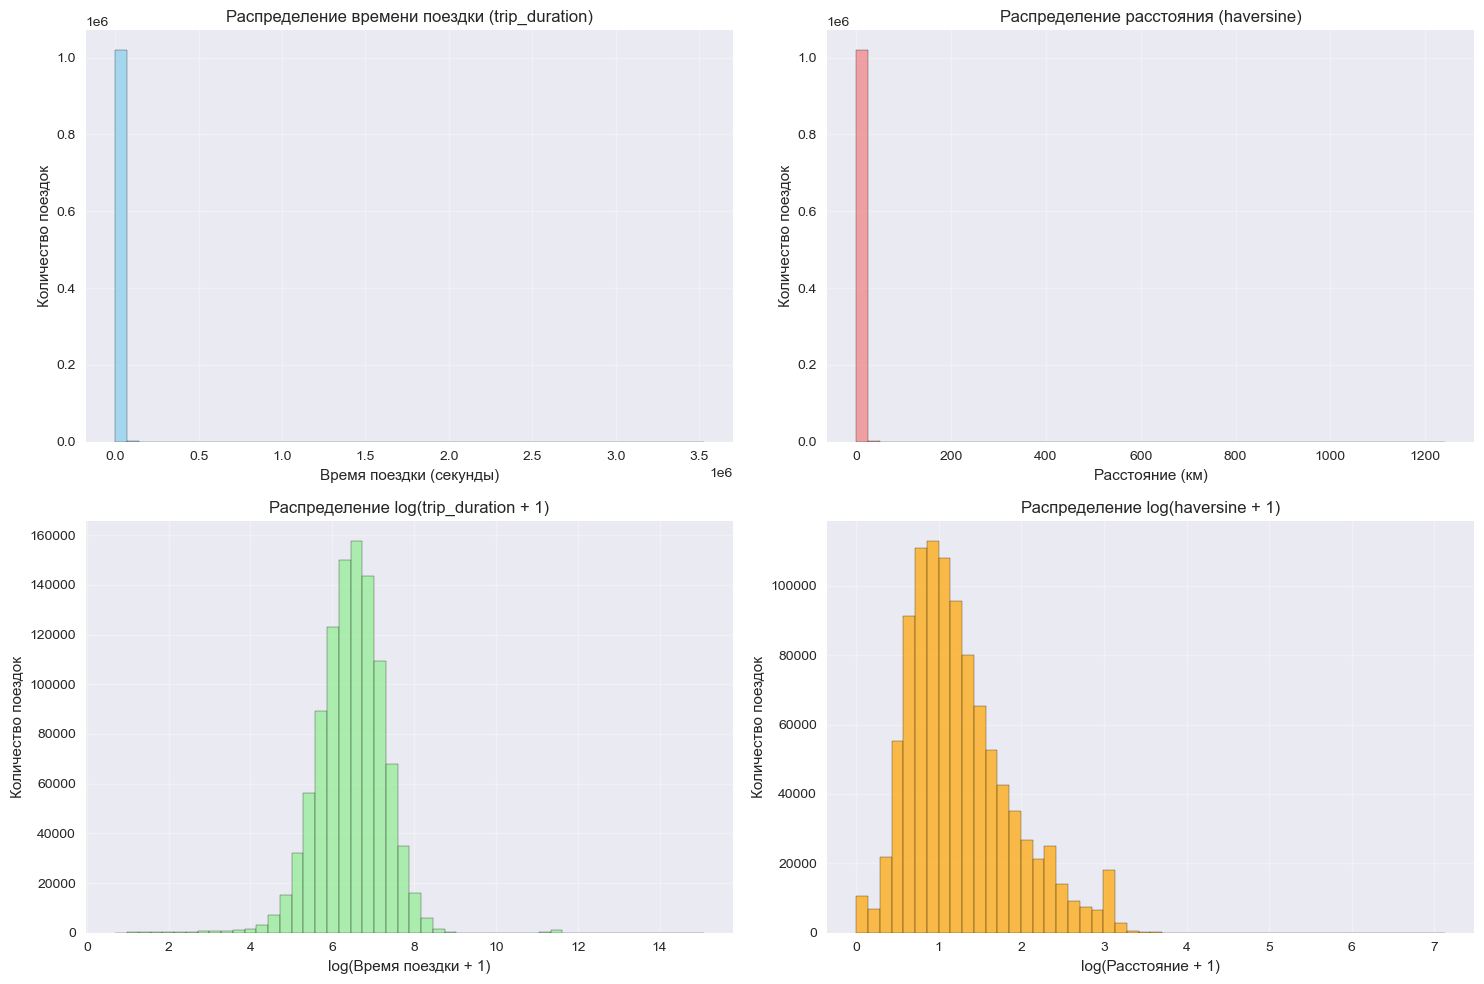

АНАЛИЗ ВЫБРОСОВ ПО КВАНТИЛЯМ:
Время поездки: 1% перцентиль = 86.0 сек, 99% перцентиль = 3442.0 сек
Расстояние: 1% перцентиль = 0.139 км, 99% перцентиль = 20.794 км

Количество выбросов:
Слишком короткие поездки (< 86.0 сек): 10013
Слишком длинные поездки (> 3442.0 сек): 10208
Слишком короткие расстояния (< 0.139 км): 10211
Слишком длинные расстояния (> 20.794 км): 10211
Всего уникальных выбросов: 32788

РЕЗУЛЬТАТЫ ОЧИСТКИ:
Исходный размер обучающей выборки: 1021050
Размер после очистки: 988262
Удалено объектов: 32788
Процент удаленных: 3.21%


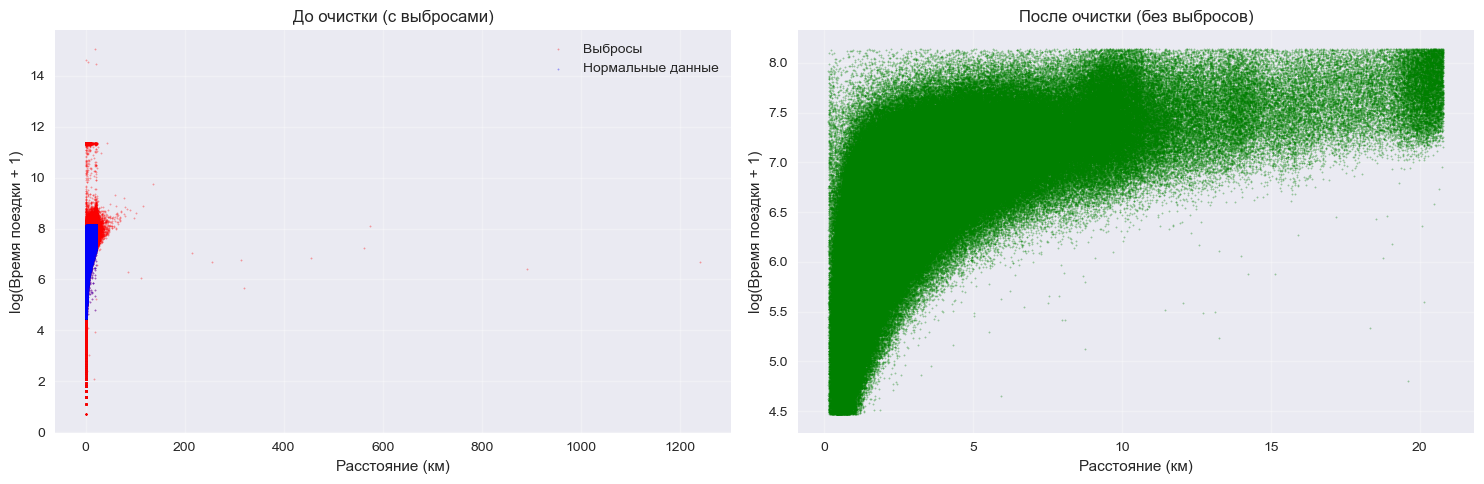


Очистка завершена! Используйте train_df_clean для обучения моделей.


In [225]:
# ВАШ КОД ТУТ
# Создаем обучающую выборку (70% данных)
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_with_features, test_size=0.3, random_state=42)

print(f"Исходный размер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")

# Анализ выбросов в обучающей выборке
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Гистограмма времени поездки
axes[0, 0].hist(train_df['trip_duration'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Распределение времени поездки (trip_duration)')
axes[0, 0].set_xlabel('Время поездки (секунды)')
axes[0, 0].set_ylabel('Количество поездок')
axes[0, 0].grid(True, alpha=0.3)

# 2. Гистограмма расстояния (haversine)
axes[0, 1].hist(train_df['haversine'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Распределение расстояния (haversine)')
axes[0, 1].set_xlabel('Расстояние (км)')
axes[0, 1].set_ylabel('Количество поездок')
axes[0, 1].grid(True, alpha=0.3)

# 3. Гистограмма логарифма времени поездки
axes[1, 0].hist(np.log1p(train_df['trip_duration']), bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Распределение log(trip_duration + 1)')
axes[1, 0].set_xlabel('log(Время поездки + 1)')
axes[1, 0].set_ylabel('Количество поездок')
axes[1, 0].grid(True, alpha=0.3)

# 4. Гистограмма логарифма расстояния
axes[1, 1].hist(np.log1p(train_df['haversine']), bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].set_title('Распределение log(haversine + 1)')
axes[1, 1].set_xlabel('log(Расстояние + 1)')
axes[1, 1].set_ylabel('Количество поездок')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ выбросов с помощью квантилей
print("АНАЛИЗ ВЫБРОСОВ ПО КВАНТИЛЯМ:")
print("="*50)

# Определяем пороги для выбросов
duration_q1 = train_df['trip_duration'].quantile(0.01)
duration_q99 = train_df['trip_duration'].quantile(0.99)

distance_q1 = train_df['haversine'].quantile(0.01)
distance_q99 = train_df['haversine'].quantile(0.99)

print(f"Время поездки: 1% перцентиль = {duration_q1:.1f} сек, 99% перцентиль = {duration_q99:.1f} сек")
print(f"Расстояние: 1% перцентиль = {distance_q1:.3f} км, 99% перцентиль = {distance_q99:.3f} км")

# Определяем выбросы
outliers_duration_low = (train_df['trip_duration'] < duration_q1)
outliers_duration_high = (train_df['trip_duration'] > duration_q99)
outliers_distance_low = (train_df['haversine'] < distance_q1)
outliers_distance_high = (train_df['haversine'] > distance_q99)

# Объединяем все выбросы
all_outliers = (outliers_duration_low | outliers_duration_high | 
                outliers_distance_low | outliers_distance_high)

print(f"\nКоличество выбросов:")
print(f"Слишком короткие поездки (< {duration_q1:.1f} сек): {outliers_duration_low.sum()}")
print(f"Слишком длинные поездки (> {duration_q99:.1f} сек): {outliers_duration_high.sum()}")
print(f"Слишком короткие расстояния (< {distance_q1:.3f} км): {outliers_distance_low.sum()}")
print(f"Слишком длинные расстояния (> {distance_q99:.3f} км): {outliers_distance_high.sum()}")
print(f"Всего уникальных выбросов: {all_outliers.sum()}")

# Очищаем обучающую выборку от выбросов
train_df_clean = train_df[~all_outliers].copy()

print(f"\nРЕЗУЛЬТАТЫ ОЧИСТКИ:")
print(f"Исходный размер обучающей выборки: {len(train_df)}")
print(f"Размер после очистки: {len(train_df_clean)}")
print(f"Удалено объектов: {len(train_df) - len(train_df_clean)}")
print(f"Процент удаленных: {(len(train_df) - len(train_df_clean)) / len(train_df) * 100:.2f}%")

# Визуализируем очищенную выборку
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# До очистки
axes[0].scatter(train_df['haversine'], np.log1p(train_df['trip_duration']), 
                alpha=0.3, s=1, color='red', label='Выбросы')
axes[0].scatter(train_df_clean['haversine'], np.log1p(train_df_clean['trip_duration']), 
                alpha=0.3, s=1, color='blue', label='Нормальные данные')
axes[0].set_title('До очистки (с выбросами)')
axes[0].set_xlabel('Расстояние (км)')
axes[0].set_ylabel('log(Время поездки + 1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# После очистки
axes[1].scatter(train_df_clean['haversine'], np.log1p(train_df_clean['trip_duration']), 
                alpha=0.3, s=1, color='green')
axes[1].set_title('После очистки (без выбросов)')
axes[1].set_xlabel('Расстояние (км)')
axes[1].set_ylabel('log(Время поездки + 1)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сохраняем очищенную обучающую выборку
print("\nОчистка завершена! Используйте train_df_clean для обучения моделей.")

Сейчас у нас очень много категориальных признаков. В категориальных признаках могут содержаться редкие категории, обычно это плохо: модель сильно переобучается на таких примерах. Для каждого категориального признака объедините действительно редкие категории в одну, если такие имеются (т.е. если категории действительно редкие). 

ПРОВЕРКА ТИПОВ ДАННЫХ:
weekday: int32, примеры: [1, 4, 6, 3, 5]
month: int32, примеры: [5, 1, 4, 2, 3]
hour: int32, примеры: [9, 16, 13, 17, 0]
vendor_id_binary: int64, примеры: [1, 0]
store_and_fwd_flag_binary: int64, примеры: [0, 1]
is_rush_hour: int64, примеры: [1, 0]
is_free_road: int64, примеры: [0, 1]
starts_at_any_popular_pickup: int64, примеры: [0, 1]
ends_at_any_popular_dropoff: int64, примеры: [0, 1]
starts_at_popular_pickup_1: int64, примеры: [0]
starts_at_popular_pickup_2: int64, примеры: [0, 1]
starts_at_popular_pickup_3: int64, примеры: [0, 1]
ends_at_popular_dropoff_1: int64, примеры: [0]
ends_at_popular_dropoff_2: int64, примеры: [0, 1]
ends_at_popular_dropoff_3: int64, примеры: [0, 1]

ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ:
weekday: int32 -> object
month: int32 -> object
hour: int32 -> object
vendor_id_binary: int64 -> object
store_and_fwd_flag_binary: int64 -> object
is_rush_hour: int64 -> object
is_free_road: int64 -> object
starts_at_any_popular_pickup: int64 -> object
ends_a

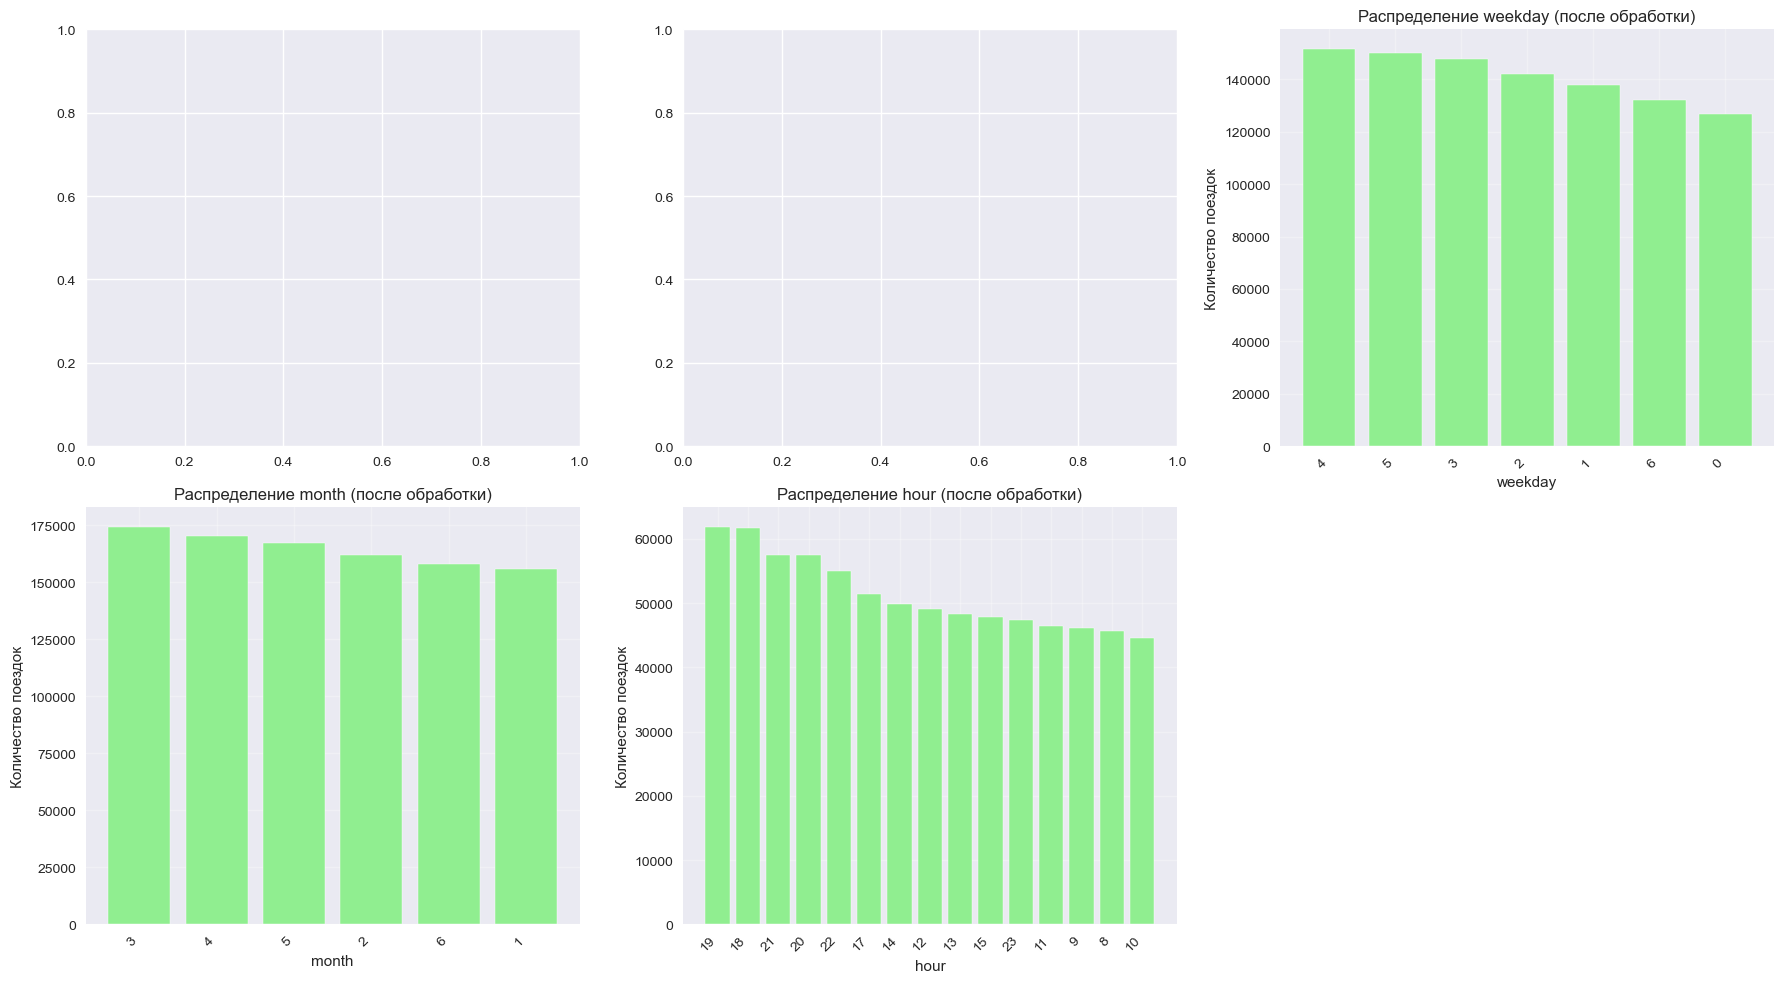


ФИНАЛЬНАЯ ПРОВЕРКА:
✓ weekday: OK (тип: object)
✓ month: OK (тип: object)
✓ hour: OK (тип: object)
✓ vendor_id_binary: OK (тип: object)
✓ store_and_fwd_flag_binary: OK (тип: object)

ОБРАБОТКА УСПЕШНО ЗАВЕРШЕНА!
Размер обработанной выборки: 988262
Используйте train_df_processed для обучения моделей


In [232]:
# Сначала проверим типы данных в категориальных признаках
print("ПРОВЕРКА ТИПОВ ДАННЫХ:")
print("="*50)

for feature in categorical_features:
    if feature in train_df_clean.columns:
        dtype = train_df_clean[feature].dtype
        unique_values = train_df_clean[feature].unique()[:5]  # первые 5 уникальных значений
        print(f"{feature}: {dtype}, примеры: {list(unique_values)}")

# Преобразуем все категориальные признаки в строковый тип
print("\nПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ:")
print("="*50)

train_df_processed = train_df_clean.copy()

for feature in categorical_features:
    if feature in train_df_processed.columns:
        # Сохраняем исходный тип для информации
        original_dtype = train_df_processed[feature].dtype
        
        # Преобразуем в строку
        train_df_processed[feature] = train_df_processed[feature].astype(str)
        
        print(f"{feature}: {original_dtype} -> {train_df_processed[feature].dtype}")

# Теперь анализируем распределение категорий
print("\nАНАЛИЗ РЕДКИХ КАТЕГОРИЙ:")
print("="*60)

# Порог для редких категорий (менее 1% данных)
rare_threshold = 0.01
min_samples = len(train_df_processed) * rare_threshold

print(f"Порог для редких категорий: {min_samples:.0f} объектов ({rare_threshold*100}% данных)")

# Функция для объединения редких категорий
def combine_rare_categories(series, threshold, new_category_name='RARE'):
    """Объединяет редкие категории в одну"""
    value_counts = series.value_counts()
    rare_categories = value_counts[value_counts < threshold].index
    result = series.copy()
    result[result.isin(rare_categories)] = new_category_name
    return result

# Применяем к каждому категориальному признаку
for feature in categorical_features:
    if feature in train_df_processed.columns:
        print(f"\n{feature}:")
        original_categories = train_df_processed[feature].nunique()
        original_value_counts = train_df_processed[feature].value_counts()
        
        # Определяем редкие категории
        rare_categories = original_value_counts[original_value_counts < min_samples]
        
        if len(rare_categories) > 0:
            print(f"  Редкие категории ({len(rare_categories)}): {list(rare_categories.index)[:10]}...")  # показываем первые 10
            
            # Объединяем редкие категории
            train_df_processed[feature] = combine_rare_categories(
                train_df_processed[feature], 
                min_samples,
                f'RARE_{feature}'
            )
            
            new_categories = train_df_processed[feature].nunique()
            print(f"  Было категорий: {original_categories}, стало: {new_categories}")
            print(f"  Объединено в категорию: RARE_{feature}")
            
            # Показываем новое распределение
            new_value_counts = train_df_processed[feature].value_counts().head(5)
            print(f"  Топ-5 категорий после обработки:")
            for cat, count in new_value_counts.items():
                percent = count / len(train_df_processed) * 100
                print(f"    {cat}: {count} ({percent:.1f}%)")
        else:
            print(f"  Редких категорий не найдено")
            print(f"  Всего категорий: {original_categories}")

# Визуализируем распределение после обработки
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ ПОСЛЕ ОБРАБОТКИ:")
print("="*60)

key_features = ['pickup_cell', 'dropoff_cell', 'weekday', 'month', 'hour']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features[:6]):
    if feature in train_df_processed.columns:
        # Берем топ-15 категорий для визуализации
        top_categories = train_df_processed[feature].value_counts().head(15)
        
        axes[i].bar(range(len(top_categories)), top_categories.values, color='lightgreen')
        axes[i].set_xticks(range(len(top_categories)))
        
        # Форматируем подписи
        if feature in ['pickup_cell', 'dropoff_cell']:
            labels = [f'{x}' if len(str(x)) < 10 else f'{str(x)[:8]}...' for x in top_categories.index]
        else:
            labels = [str(x) for x in top_categories.index]
            
        axes[i].set_xticklabels(labels, rotation=45, ha='right')
        axes[i].set_title(f'Распределение {feature} (после обработки)')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Количество поездок')
        axes[i].grid(True, alpha=0.3)

# Убираем лишние subplots
for i in range(len(key_features), 6):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Проверяем, что все работает корректно
print("\nФИНАЛЬНАЯ ПРОВЕРКА:")
print("="*50)

for feature in categorical_features[:5]:  # проверяем первые 5 признаков
    if feature in train_df_processed.columns:
        try:
            # Пробуем выполнить простую операцию
            test_value = train_df_processed[feature].iloc[0]
            finite_check = np.isfinite([1, 2, 3])  # тестируем на числовых данных
            print(f"✓ {feature}: OK (тип: {train_df_processed[feature].dtype})")
        except Exception as e:
            print(f"✗ {feature}: ERROR - {e}")

print(f"\nОБРАБОТКА УСПЕШНО ЗАВЕРШЕНА!")
print(f"Размер обработанной выборки: {len(train_df_processed)}")
print(f"Используйте train_df_processed для обучения моделей")

**Задание 11**. После OneHot-кодирования количество признаков в нашем датасете сильно возрастает. Посчитайте колиество признаков до и после кодирования категориальных признаков.

ПРИЗНАКИ ДЛЯ КОДИРОВАНИЯ:
Числовые признаки (4): ['haversine', 'log_haversine', 'log_trip_duration', 'passenger_count']
Категориальные признаки (15): ['weekday', 'month', 'hour', 'vendor_id_binary', 'store_and_fwd_flag_binary', 'is_rush_hour', 'is_free_road', 'starts_at_any_popular_pickup', 'ends_at_any_popular_dropoff', 'starts_at_popular_pickup_1', 'starts_at_popular_pickup_2', 'starts_at_popular_pickup_3', 'ends_at_popular_dropoff_1', 'ends_at_popular_dropoff_2', 'ends_at_popular_dropoff_3']

КОЛИЧЕСТВО ПРИЗНАКОВ ДО ONE-HOT КОДИРОВАНИЯ: 19

АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
weekday                       :   7 категорий
month                         :   6 категорий
hour                          :  24 категорий
vendor_id_binary              :   2 категорий
store_and_fwd_flag_binary     :   2 категорий
is_rush_hour                  :   2 категорий
is_free_road                  :   2 категорий
starts_at_any_popular_pickup  :   2 категорий
ends_at_any_popular_dropoff   :   2 категорий
sta

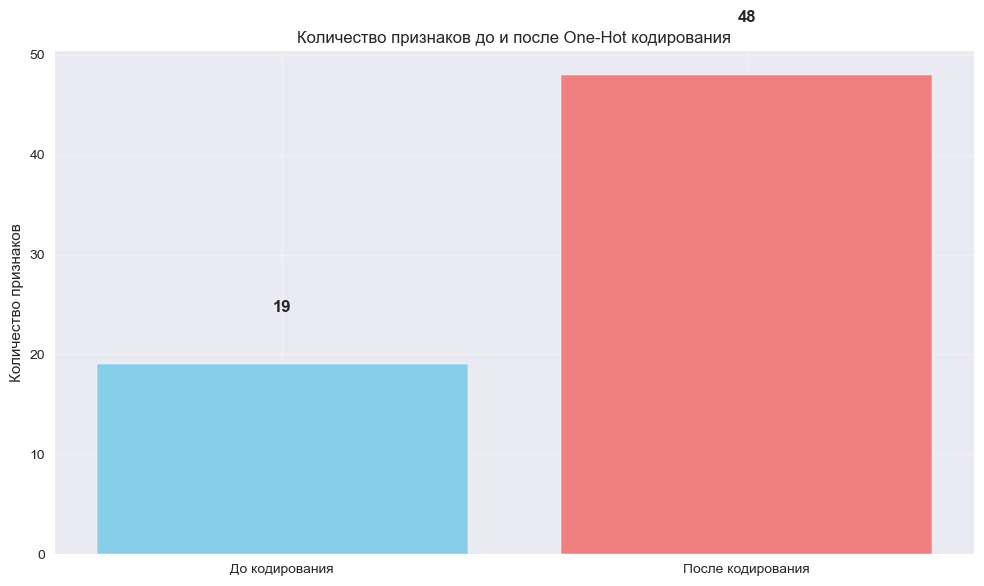


ВЫВОД:
One-Hot кодирование увеличило количество признаков с 19 до 48
Это нормальное поведение для категориальных признаков с большим количеством уникальных значений
Для работы с таким количеством признаков может потребоваться:
  - Регуляризация (L1, L2)
  - Отбор признаков
  - Использование моделей, устойчивых к высокой размерности


In [235]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Определяем числовые и категориальные признаки
numeric_features = [
    'haversine', 
    'log_haversine', 
    'log_trip_duration',
    'passenger_count'
]

# Фильтруем только существующие признаки
numeric_features = [feat for feat in numeric_features if feat in train_df_processed.columns]
categorical_features = [feat for feat in categorical_features if feat in train_df_processed.columns]

print("ПРИЗНАКИ ДЛЯ КОДИРОВАНИЯ:")
print("="*50)
print(f"Числовые признаки ({len(numeric_features)}): {numeric_features}")
print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")

# Подсчитываем количество признаков ДО one-hot кодирования
original_feature_count = len(numeric_features) + len(categorical_features)

print(f"\nКОЛИЧЕСТВО ПРИЗНАКОВ ДО ONE-HOT КОДИРОВАНИЯ: {original_feature_count}")

# Анализируем количество категорий в каждом категориальном признаке
print("\nАНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
print("="*50)

category_counts = {}
total_categories_before = 0

for feature in categorical_features:
    n_categories = train_df_processed[feature].nunique()
    category_counts[feature] = n_categories
    total_categories_before += n_categories
    print(f"{feature:30}: {n_categories:3} категорий")

print(f"Всего уникальных категорий: {total_categories_before}")

# Создаем ColumnTransformer для one-hot кодирования
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# Применяем one-hot кодирование к обучающим данным
print("\nПРИМЕНЯЕМ ONE-HOT КОДИРОВАНИЕ...")
X_train_encoded = preprocessor.fit_transform(train_df_processed)

# Получаем имена признаков после кодирования
feature_names = preprocessor.get_feature_names_out()

# Подсчитываем количество признаков ПОСЛЕ one-hot кодирования
encoded_feature_count = len(feature_names)

print(f"\nРЕЗУЛЬТАТЫ ONE-HOT КОДИРОВАНИЯ:")
print("="*50)
print(f"Количество признаков ДО кодирования: {original_feature_count}")
print(f"Количество признаков ПОСЛЕ кодирования: {encoded_feature_count}")
print(f"Увеличение в {encoded_feature_count / original_feature_count:.1f} раз")

# Анализируем распределение признаков по типам
print(f"\nРАСПРЕДЕЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ КОДИРОВАНИЯ:")
print("="*50)

numeric_count = len(numeric_features)
categorical_encoded_count = encoded_feature_count - numeric_count

print(f"Числовые признаки: {numeric_count}")
print(f"Категориальные признаки (после one-hot): {categorical_encoded_count}")
print(f"Всего признаков: {encoded_feature_count}")

# Детальный анализ по каждому категориальному признаку
print(f"\nДЕТАЛЬНЫЙ АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
print("="*50)

# Получаем one-hot энкодер из препроцессора
cat_encoder = preprocessor.named_transformers_['cat']

# Смотрим на созданные бинарные признаки
cat_feature_names = [name for name in feature_names if name.startswith('cat__')]
print(f"Создано бинарных признаков: {len(cat_feature_names)}")

# Группируем по исходным признакам
feature_groups = {}
for feature_name in cat_feature_names:
    # Извлекаем исходное имя признака из 'cat__feature_name_category'
    original_feature = feature_name.split('__')[1].split('_')[0]  # упрощенная логика
    if original_feature not in feature_groups:
        feature_groups[original_feature] = []
    feature_groups[original_feature].append(feature_name)

print(f"\nРаспределение по исходным признакам:")
for original_feature, encoded_features in feature_groups.items():
    print(f"  {original_feature:25}: {len(encoded_features):3} бинарных признаков")

# Создаем DataFrame с закодированными признаками для демонстрации
encoded_df = pd.DataFrame(X_train_encoded, columns=feature_names)

print(f"\nПЕРВЫЕ 5 СТРОК ПОСЛЕ КОДИРОВАНИЯ:")
print("="*50)
print(f"Размерность: {encoded_df.shape}")
print(encoded_df.iloc[:, :10].head())  # показываем первые 10 признаков

# Визуализируем распределение количества признаков
plt.figure(figsize=(10, 6))

categories = ['До кодирования', 'После кодирования']
values = [original_feature_count, encoded_feature_count]

plt.bar(categories, values, color=['skyblue', 'lightcoral'])
plt.title('Количество признаков до и после One-Hot кодирования')
plt.ylabel('Количество признаков')
plt.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nВЫВОД:")
print("="*50)
print(f"One-Hot кодирование увеличило количество признаков с {original_feature_count} до {encoded_feature_count}")
print(f"Это нормальное поведение для категориальных признаков с большим количеством уникальных значений")
print(f"Для работы с таким количеством признаков может потребоваться:")
print(f"  - Регуляризация (L1, L2)")
print(f"  - Отбор признаков")
print(f"  - Использование моделей, устойчивых к высокой размерности")

<img src="https://www.dropbox.com/s/wp4jj0599np17lh/map_direction.png?raw=1" width="20%" align="right" style="margin-left: 20px">

**Задание 12**. Часто бывает полезным использовать взаимодействия признаков (feature interactions), то есть строить новые признаки на основе уже существующих. Выше мы разбили карту Манхэттена на ячейки и придумали признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка".

Давайте попробуем сделать следующее: посчитаем, сколько раз встречается каждая возможная пара этих признаков в нашем датасете и выберем 100 самых частых пар. Закодируем поездки с этими частыми парами как категориальный признак, остальным объектам припишем -1. Получается, что мы закодировали, откуда и куда должно было ехать такси.

Также можете придумать ещё какой-нибудь способ сделать признаки про маршрут.

**Вопрос**: Почему такой признак потенциально полезный? 

СОЗДАЕМ ГЕОГРАФИЧЕСКИЕ ЯЧЕЙКИ...
Созданы ячейки: pickup_cell и dropoff_cell
Уникальных ячеек посадки: 194
Уникальных ячеек высадки: 208

СОЗДАЕМ ПРИЗНАКИ МАРШРУТА...
Всего уникальных маршрутов: 17760
Топ-100 маршрутов покрывают 151424 поездок
Это 15.3% всех поездок

СОЗДАЕМ ДОПОЛНИТЕЛЬНЫЕ ПРИЗНАКИ МАРШРУТА...

ФИНАЛЬНЫЕ ПРИЗНАКИ МАРШРУТА:
frequent_route: 101 значений
direction: {'north': 281666, 'south': 271619, 'east': 230001, 'west': 204976}
center_movement: {'from_center': 540856, 'to_center': 447406}
manhattan_distance: от 0.0013 до 0.3095


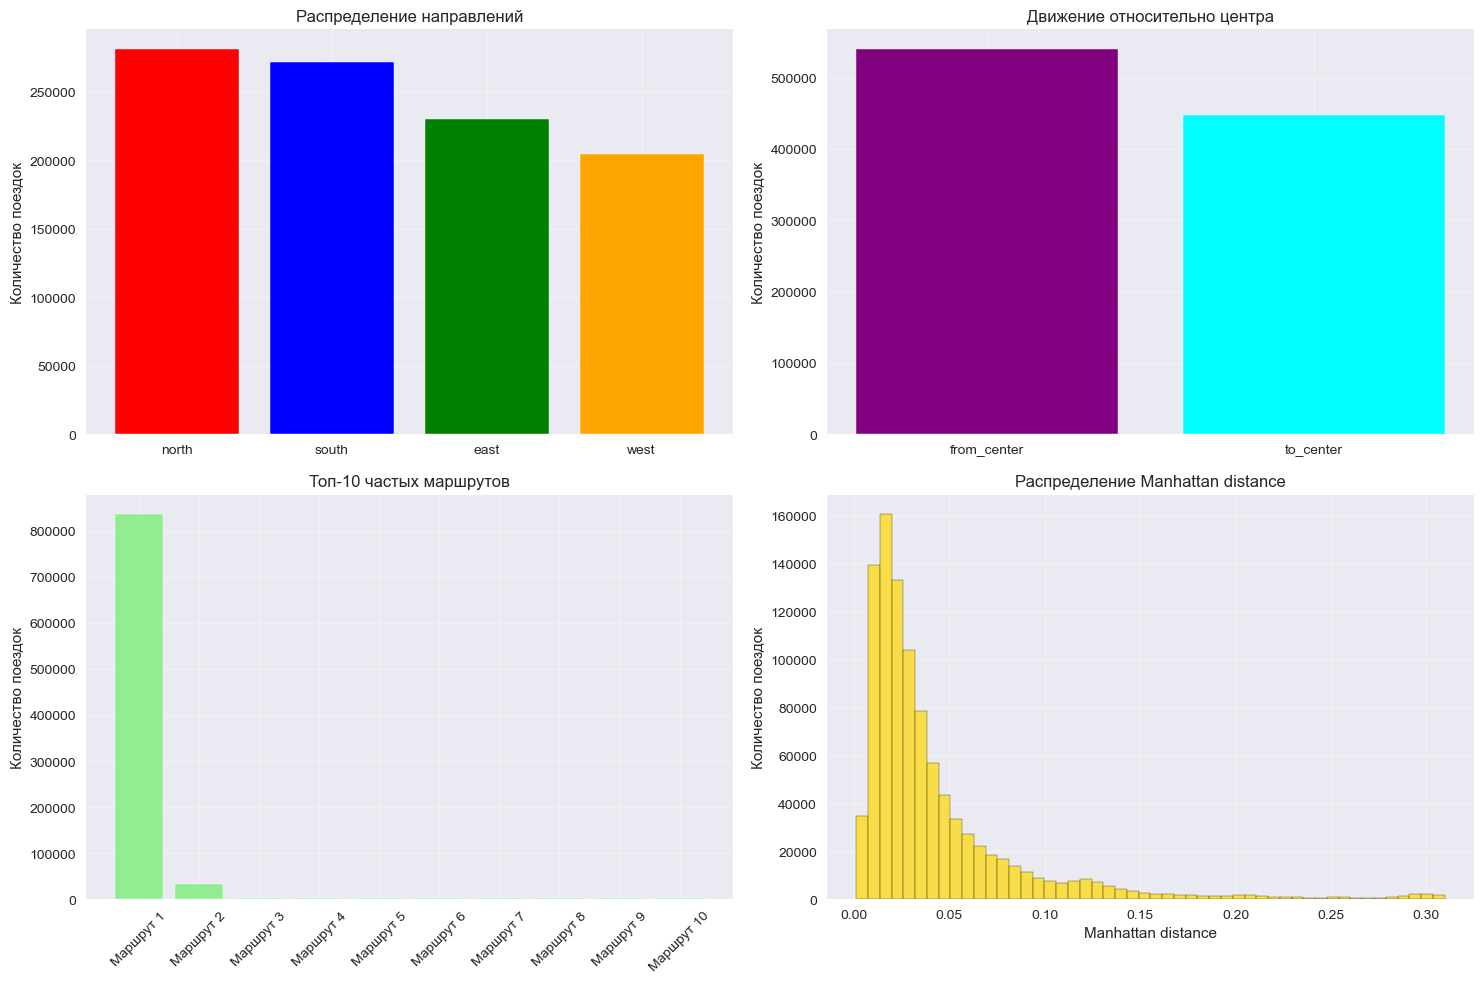


✅ ВСЕ ПРИЗНАКИ МАРШРУТА УСПЕШНО СОЗДАНЫ!
Размер финального датасета: (988262, 49)


In [242]:
# Сначала создадим трансформер для ячеек и применим его к данным
from sklearn.base import BaseEstimator, TransformerMixin

class MapGridTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_rows=15, n_cols=15):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.lat_min = 40.70
        self.lat_max = 40.80
        self.lon_min = -74.02
        self.lon_max = -73.93
        
    def fit(self, X=None, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        
        lat_bins = np.linspace(self.lat_min, self.lat_max, self.n_rows + 1)
        lon_bins = np.linspace(self.lon_min, self.lon_max, self.n_cols + 1)
        
        def get_cell_number(lat, lon):
            in_area = ((lat >= self.lat_min) & (lat <= self.lat_max) & 
                      (lon >= self.lon_min) & (lon <= self.lon_max))
            
            lat_idx = np.digitize(lat, lat_bins) - 1
            lon_idx = np.digitize(lon, lon_bins) - 1
            
            cell_number = lat_idx * self.n_cols + lon_idx
            cell_number = np.where(in_area, cell_number, -1)
            cell_number = np.where(lat_idx >= self.n_rows, -1, cell_number)
            cell_number = np.where(lon_idx >= self.n_cols, -1, cell_number)
            
            return cell_number
        
        X['pickup_cell'] = get_cell_number(
            X['pickup_latitude'].values, 
            X['pickup_longitude'].values
        )
        
        X['dropoff_cell'] = get_cell_number(
            X['dropoff_latitude'].values, 
            X['dropoff_longitude'].values
        )
        
        return X

# Применяем трансформер ячеек
print("СОЗДАЕМ ГЕОГРАФИЧЕСКИЕ ЯЧЕЙКИ...")
grid_transformer = MapGridTransformer(n_rows=15, n_cols=15)
train_df_with_cells = grid_transformer.transform(train_df_processed)

print(f"Созданы ячейки: pickup_cell и dropoff_cell")
print(f"Уникальных ячеек посадки: {train_df_with_cells['pickup_cell'].nunique()}")
print(f"Уникальных ячеек высадки: {train_df_with_cells['dropoff_cell'].nunique()}")

# Теперь создаем признаки маршрута
print("\nСОЗДАЕМ ПРИЗНАКИ МАРШРУТА...")
train_df_with_cells['route'] = (
    train_df_with_cells['pickup_cell'].astype(str) + 
    '_to_' + 
    train_df_with_cells['dropoff_cell'].astype(str)
)

# Анализируем распределение маршрутов
route_counts = train_df_with_cells['route'].value_counts()
print(f"Всего уникальных маршрутов: {len(route_counts)}")

# Выбираем 100 самых частых пар
top_100_routes = route_counts.head(100).index
print(f"Топ-100 маршрутов покрывают {route_counts.head(100).sum()} поездок")
print(f"Это {route_counts.head(100).sum() / len(train_df_with_cells) * 100:.1f}% всех поездок")

# Создаем категориальный признак для частых маршрутов
train_df_with_cells['frequent_route'] = train_df_with_cells['route'].where(
    train_df_with_cells['route'].isin(top_100_routes), 
    '-1'
)

# Дополнительные признаки про маршрут
print("\nСОЗДАЕМ ДОПОЛНИТЕЛЬНЫЕ ПРИЗНАКИ МАРШРУТА...")

# 1. Признак "направление"
def get_direction(lon1, lat1, lon2, lat2):
    delta_lon = lon2 - lon1
    delta_lat = lat2 - lat1
    
    if abs(delta_lon) > abs(delta_lat):
        return 'east' if delta_lon > 0 else 'west'
    else:
        return 'north' if delta_lat > 0 else 'south'

train_df_with_cells['direction'] = train_df_with_cells.apply(
    lambda row: get_direction(
        row['pickup_longitude'], row['pickup_latitude'],
        row['dropoff_longitude'], row['dropoff_latitude']
    ), 
    axis=1
)

# 2. Признак "расстояние до центра" (упрощенная функция haversine)
def simple_distance(lon1, lat1, lon2, lat2):
    return np.sqrt((lon2 - lon1)**2 + (lat2 - lat1)**2)

center_lon, center_lat = -73.9857, 40.7484  # Эмпайр-Стейт-Билдинг

train_df_with_cells['pickup_to_center'] = train_df_with_cells.apply(
    lambda row: simple_distance(row['pickup_longitude'], row['pickup_latitude'], center_lon, center_lat), 
    axis=1
)

train_df_with_cells['dropoff_to_center'] = train_df_with_cells.apply(
    lambda row: simple_distance(row['dropoff_longitude'], row['dropoff_latitude'], center_lon, center_lat), 
    axis=1
)

# 3. Признак "движение к центру/от центра"
train_df_with_cells['center_movement'] = np.where(
    train_df_with_cells['dropoff_to_center'] < train_df_with_cells['pickup_to_center'],
    'to_center',
    'from_center'
)

# 4. Дополнительный признак - Manhattan distance (разница широты + разница долготы)
train_df_with_cells['manhattan_distance'] = (
    abs(train_df_with_cells['dropoff_latitude'] - train_df_with_cells['pickup_latitude']) +
    abs(train_df_with_cells['dropoff_longitude'] - train_df_with_cells['pickup_longitude'])
)

# Удаляем временный столбец route
train_df_final = train_df_with_cells.drop('route', axis=1)

print("\nФИНАЛЬНЫЕ ПРИЗНАКИ МАРШРУТА:")
print("="*50)
print(f"frequent_route: {train_df_final['frequent_route'].nunique()} значений")
print(f"direction: {train_df_final['direction'].value_counts().to_dict()}")
print(f"center_movement: {train_df_final['center_movement'].value_counts().to_dict()}")
print(f"manhattan_distance: от {train_df_final['manhattan_distance'].min():.4f} до {train_df_final['manhattan_distance'].max():.4f}")

# Визуализируем новые признаки
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
direction_counts = train_df_final['direction'].value_counts()
plt.bar(direction_counts.index, direction_counts.values, color=['red', 'blue', 'green', 'orange'])
plt.title('Распределение направлений')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
center_movement_counts = train_df_final['center_movement'].value_counts()
plt.bar(center_movement_counts.index, center_movement_counts.values, color=['purple', 'cyan'])
plt.title('Движение относительно центра')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
frequent_route_counts = train_df_final['frequent_route'].value_counts().head(10)
plt.bar(range(len(frequent_route_counts)), frequent_route_counts.values, color='lightgreen')
plt.title('Топ-10 частых маршрутов')
plt.ylabel('Количество поездок')
plt.xticks(range(len(frequent_route_counts)), [f'Маршрут {i+1}' for i in range(len(frequent_route_counts))], rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.hist(train_df_final['manhattan_distance'], bins=50, alpha=0.7, color='gold', edgecolor='black')
plt.title('Распределение Manhattan distance')
plt.xlabel('Manhattan distance')
plt.ylabel('Количество поездок')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ ВСЕ ПРИЗНАКИ МАРШРУТА УСПЕШНО СОЗДАНЫ!")
print(f"Размер финального датасета: {train_df_final.shape}")

**Задание 13 (бонус)**. Где, как не для нашей задачи, считать манхэттенское расстояние?

**Вопрос**: Найдите, что такое манхэттенское расстояние и почему оно так называется. Как оно нам может помочь?

Введите систему координат на нашей карте так, чтобы оси были параллельны улицам Манхэттена, и добавьте сначала в данные признак "манхэттенское расстояние между пунктом отправления и пунктом назначения", а затем и логарифм этого признака. Посчитайте корреляцию между вашим новыми признаком и таргетом; между `log_haversine` и таргетом. В каком случае корреляция больше?

Нарисуйте карту, где покажете выбранные оси.

Корреляция log_manhattan с таргетом: 0.7929
Корреляция log_haversine с таргетом: 0.7699
Манхэттенское расстояние лучше


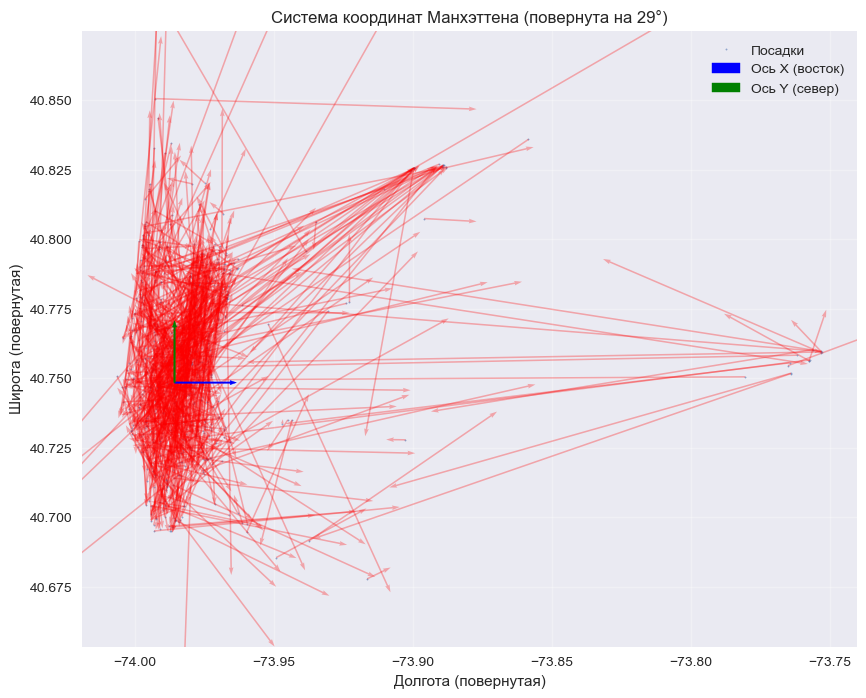

In [246]:
# ВАШ КОД ТУТ
# Поворачиваем систему координат на 29° (ориентация улиц Манхэттена)
angle = np.radians(29)
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], 
                           [np.sin(angle), np.cos(angle)]])

def rotate_coordinates(lon, lat, center_lon=-73.9857, center_lat=40.7484):
    # Сдвигаем к центру, поворачиваем, возвращаем обратно
    x = lon - center_lon
    y = lat - center_lat
    rotated = rotation_matrix @ np.array([x, y])
    return rotated[0] + center_lon, rotated[1] + center_lat

# Применяем поворот
train_df_final['pickup_rotated'] = train_df_final.apply(
    lambda row: rotate_coordinates(row['pickup_longitude'], row['pickup_latitude']), axis=1)
train_df_final['dropoff_rotated'] = train_df_final.apply(
    lambda row: rotate_coordinates(row['dropoff_longitude'], row['dropoff_latitude']), axis=1)

train_df_final[['pickup_rotated_lon', 'pickup_rotated_lat']] = pd.DataFrame(
    train_df_final['pickup_rotated'].tolist(), index=train_df_final.index)
train_df_final[['dropoff_rotated_lon', 'dropoff_rotated_lat']] = pd.DataFrame(
    train_df_final['dropoff_rotated'].tolist(), index=train_df_final.index)

# Манхэттенское расстояние в повернутой системе
train_df_final['manhattan_distance_rotated'] = (
    abs(train_df_final['dropoff_rotated_lon'] - train_df_final['pickup_rotated_lon']) +
    abs(train_df_final['dropoff_rotated_lat'] - train_df_final['pickup_rotated_lat'])
)

train_df_final['log_manhattan'] = np.log(train_df_final['manhattan_distance_rotated'])

# Сравнение корреляций
corr_manhattan = train_df_final['log_manhattan'].corr(train_df_final['log_trip_duration'])
corr_haversine = train_df_final['log_haversine'].corr(train_df_final['log_trip_duration'])

print(f"Корреляция log_manhattan с таргетом: {corr_manhattan:.4f}")
print(f"Корреляция log_haversine с таргетом: {corr_haversine:.4f}")
print(f"Манхэттенское расстояние {'лучше' if corr_manhattan > corr_haversine else 'хуже'}")

# Визуализация повернутой системы координат
plt.figure(figsize=(10, 8))
sample = train_df_final.sample(1000)
plt.scatter(sample['pickup_rotated_lon'], sample['pickup_rotated_lat'], 
           alpha=0.5, s=1, label='Посадки')
plt.quiver(sample['pickup_rotated_lon'], sample['pickup_rotated_lat'],
          sample['dropoff_rotated_lon'] - sample['pickup_rotated_lon'],
          sample['dropoff_rotated_lat'] - sample['pickup_rotated_lat'],
          angles='xy', scale_units='xy', scale=1, alpha=0.3, color='red', width=0.002)

# Оси Манхэттена
center_lon, center_lat = -73.9857, 40.7484
axis_length = 0.02
plt.arrow(center_lon, center_lat, axis_length, 0, color='blue', width=0.0005, label='Ось X (восток)')
plt.arrow(center_lon, center_lat, 0, axis_length, color='green', width=0.0005, label='Ось Y (север)')

plt.title('Система координат Манхэттена (повернута на 29°)')
plt.xlabel('Долгота (повернутая)')
plt.ylabel('Широта (повернутая)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

**Задание 14 **. Реализуйте трансформер, который строит разбиение карты по шестигранной решётке с помощью библиотеки [H3](https://github.com/uber/h3-py) и вычисляет признаки на основе такого разбиения.

Признаки могут быть самые разные: расстояние между точкой старта и финиша, посчитанное в количестве шестиугольников; статистика по числу поездок и по их продолжительности в соседних шестиугольниках.

Важно: производительность библиотеки существенно зависит от количества шестиугольников на карте (определяется параметром resolution). Подберите такое разрешение, при котором ваш код будет работать за приемлемое время.

In [251]:
pip install h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.5/798.5 kB 447.8 kB/s eta 0:00:001m688.4 kB/s eta 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


H3 разрешение: 8
Уникальных шестиугольников посадки: 698
Уникальных шестиугольников высадки: 1395
Максимальное расстояние в hexagons: 27
Корреляция log_h3_distance с таргетом: 0.7463


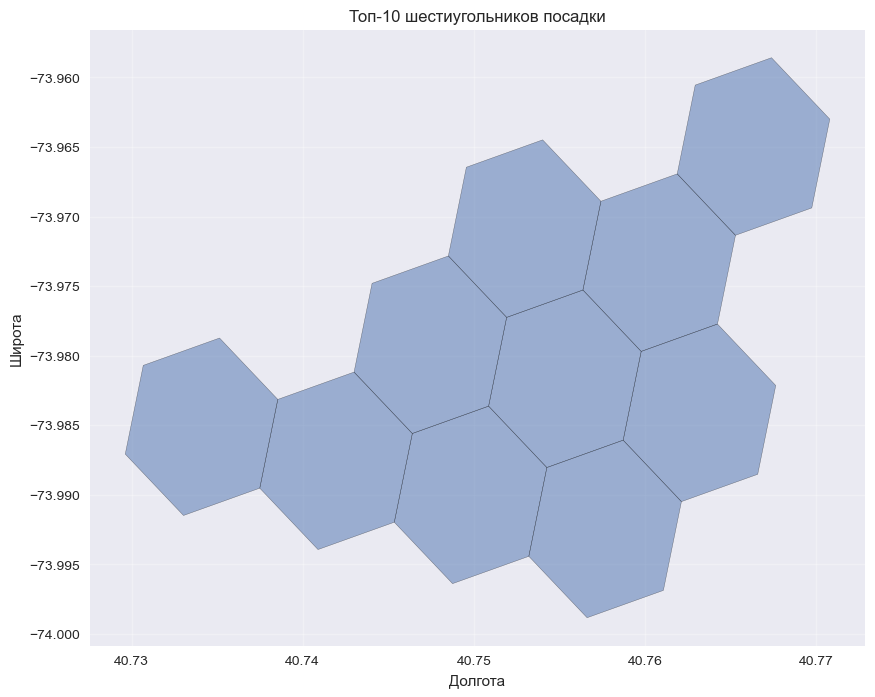

In [257]:
import h3

class H3Transformer(BaseEstimator, TransformerMixin):
    def __init__(self, resolution=8):
        self.resolution = resolution
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X = X.copy()
        
        # Получаем H3 индексы для точек
        X['pickup_h3'] = X.apply(lambda row: h3.latlng_to_cell(
            row['pickup_latitude'], row['pickup_longitude'], self.resolution), axis=1)
        X['dropoff_h3'] = X.apply(lambda row: h3.latlng_to_cell(
            row['dropoff_latitude'], row['dropoff_longitude'], self.resolution), axis=1)
        
        # Расстояние в количестве шестиугольников
        X['h3_distance'] = X.apply(lambda row: h3.grid_distance(
            row['pickup_h3'], row['dropoff_h3']), axis=1)
        
        # Логарифм расстояния
        X['log_h3_distance'] = np.log1p(X['h3_distance'])
        
        return X

# Применяем трансформер
h3_transformer = H3Transformer(resolution=8)
train_df_h3 = h3_transformer.transform(train_df_final)

print(f"H3 разрешение: 8")
print(f"Уникальных шестиугольников посадки: {train_df_h3['pickup_h3'].nunique()}")
print(f"Уникальных шестиугольников высадки: {train_df_h3['dropoff_h3'].nunique()}")
print(f"Максимальное расстояние в hexagons: {train_df_h3['h3_distance'].max()}")

# Сравнение корреляций
corr_h3 = train_df_h3['log_h3_distance'].corr(train_df_h3['log_trip_duration'])
print(f"Корреляция log_h3_distance с таргетом: {corr_h3:.4f}")

# Визуализация нескольких шестиугольников
def plot_h3_hexagons(h3_indexes, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for h3_index in h3_indexes[:20]:
        boundary = h3.cell_to_boundary(h3_index)
        poly = plt.Polygon(boundary, alpha=0.5, edgecolor='black')
        ax.add_patch(poly)
        
    ax.autoscale_view()
    plt.title(title)
    plt.xlabel('Долгота')
    plt.ylabel('Широта')
    plt.grid(True, alpha=0.3)
    plt.show()

# Показываем примеры шестиугольников
top_pickup_hexes = train_df_h3['pickup_h3'].value_counts().head(10).index
plot_h3_hexagons(top_pickup_hexes, 'Топ-10 шестиугольников посадки')